# 📊 Weights & Biases — Experiment Tracking for Deep Learning Teams

> **What you'll learn:** W&B's building blocks (projects, runs, config, step-based logging, summaries), how to instrument a real PyTorch training loop with curves, gradient histograms, images, and prediction tables, how to version datasets and models as artifacts, how sweeps and Hyperband early termination work, and when to choose W&B vs MLflow — all **offline, without an account**, reading the run files back to prove what was logged.

| | |
|---|---|
| **Difficulty** | 🟢 Beginner → 🟡 Intermediate |
| **Optional** | Yes — [MLflow](01_MLflow.ipynb) covers the must-know tracking ideas; do this one if your team uses W&B or you train many deep-learning models |
| **Time** | ~3 hours to read and run, +1.5 hours for exercises and the project |
| **Prerequisites** | [MLflow](01_MLflow.ipynb) (runs, params, metrics, artifacts) · [PyTorch](../04_Deep_Learning/02_PyTorch.ipynb) (training loops, `nn.Module`, `DataLoader`) |
| **Tested with** | Python 3.12 · wandb 0.30 · torch 2.14 · torchvision 0.29 |
| **Interview relevance** | ⭐⭐ Medium — "how do you track DL experiments?", summary semantics (last vs best), artifact lineage, sweeps and Hyperband, W&B vs MLflow trade-offs |

## 🤔 What Is Weights & Biases?

Think of training a neural network like a long car journey. MLflow (previous notebook) is the logbook where you write down each trip. **Weights & Biases (W&B, `wandb`)** is the car's **dashboard plus a dashcam**: while the engine runs it streams live gauges (loss, accuracy, learning rate, gradient sizes), records snapshots (images, predictions), and stores the exact parts you used (datasets, checkpoints) so any trip can be replayed and compared with teammates.

| W&B word | Plain English |
|---|---|
| **entity / project** | your team / a folder of related runs |
| **run** | one execution of a training script (`wandb.init()` … `run.finish()`) |
| **config** | the settings for a run (learning rate, batch size) — like MLflow params |
| **`run.log({...}, step=)`** | add a row of values to the run's **history** at a step — like MLflow metrics |
| **summary** | one value per metric that represents the run in tables (by default: the *last* logged value) |
| **artifact** | a versioned bundle of files (dataset, model) with **lineage**: which run made it, which runs used it |
| **sweep** | a hyperparameter search coordinated by a W&B **controller** and run by **agents** |

W&B is mainly a hosted service (with a self-hosted server option). This notebook runs in **offline mode**: the library writes everything to local files, and `wandb sync` can upload them later if you create an account.

## 🎯 Why It Matters

- **Deep-learning teams live in dashboards.** Research labs and many ML teams (OpenAI, NVIDIA, Toyota Research, and thousands of startups, per W&B's customer list) use W&B to watch training live, compare hundreds of runs, and share reports.
- **Debugging training.** Loss curves, gradient histograms, and prediction tables reveal exploding gradients, overfitting, and label errors while the job is still running.
- **Reproducibility across people.** Artifacts tie a checkpoint to the exact dataset version and run that produced it.
- **In interviews** you may hear: *"How did you track your experiments?"*, *"Why does the summary show the last value, not the best?"*, *"How does Bayesian search / Hyperband work?"*, *"W&B or MLflow for this team?"* This notebook gives you concrete, verified answers.

## ✅ By the End You Can

- [ ] Start offline runs with a config, log metrics at steps, and explain summary semantics (last vs `define_metric` max/min/mean)
- [ ] Instrument a PyTorch training loop with curves, `watch` gradient histograms, images, and prediction tables
- [ ] Version datasets and models as artifacts correctly (write, close, *then* add) and explain lineage
- [ ] Read an offline run's files back and verify exactly what was logged
- [ ] Write sweep configurations (grid / random / bayes, Hyperband early termination) and explain agents
- [ ] Choose between W&B and MLflow for a given team and justify it

## 📋 Table of Contents

1. [Runs, Projects, and Config](#1.-Runs,-Projects,-and-Config-🟢)
2. [Logging Metrics with Steps](#2.-Logging-Metrics-with-Steps-🟢)
3. [Summaries: Last Value vs Best Value](#3.-Summaries:-Last-Value-vs-Best-Value-🟡)
4. [Tracking a Real PyTorch Training Loop](#4.-Tracking-a-Real-PyTorch-Training-Loop-🟡)
5. [Media and Tables](#5.-Media-and-Tables-🟡)
6. [Reading an Offline Run Back](#6.-Reading-an-Offline-Run-Back-🟡)
7. [Artifacts and Lineage](#7.-Artifacts-and-Lineage-🟡)
8. [Offline, Disabled, and Syncing Later](#8.-Offline,-Disabled,-and-Syncing-Later-🟢)
9. [Sweeps: Search Strategies and Early Termination](#9.-Sweeps:-Search-Strategies-and-Early-Termination-🔴)
10. [W&B vs MLflow: A Decision Guide](#10.-W&B-vs-MLflow:-A-Decision-Guide-🟢)
- [🔧 Build It From Scratch](#🔧-Build-It-From-Scratch) · [⚠️ Common Pitfalls](#⚠️-Common-Pitfalls) · [🏋️ Practice Exercises](#🏋️-Practice-Exercises) · [🚀 Mini Project](#🚀-Mini-Project:-A-Tracked-FashionMNIST-Classifier-with-a-Versioned-Model) · [🎤 Interview Q&A](#🎤-Interview-Q&A) · [🧪 Quick Quiz](#🧪-Quick-Quiz) · [📚 Resources](#📚-Resources) · [📝 Summary](#📝-Summary-Cheat-Sheet)

## ⚙️ Setup

Run the cell below first. If a package is missing, install it (command in the first comment), then restart the kernel.

**No account or API key is needed.** The cell sets environment variables *before* importing `wandb`:

| Variable | Value here | Why |
|---|---|---|
| `WANDB_MODE` | `offline` | write runs to disk instead of the W&B servers (`online` after `wandb login`; `disabled` turns every call into a no-op) |
| `WANDB_SILENT` | `true` | hide the banner W&B prints for every run |
| `WANDB_DIR` | `_outputs/wandb_home` | run folders go to `_outputs/wandb_home/wandb/offline-run-…` |
| `WANDB_DATA_DIR`, `WANDB_CACHE_DIR`, `WANDB_CONFIG_DIR`, `WANDB_ARTIFACT_DIR` | subfolders of `_outputs/wandb_home` | otherwise W&B stages artifacts and caches in your home directory |

The cell deletes `_outputs/wandb_home` first so every run of the notebook starts clean. Training runs on the **CPU** with 4 threads so results are repeatable and the laptop stays responsive; the models are small enough that a GPU isn't needed.

The `check()` helper gives you instant feedback on exercises: **✅** correct, **⏳** not attempted yet, **❌** wrong (with a hint).

In [1]:
# To install (then restart the kernel):  pip install "wandb>=0.30" "torch>=2.4" torchvision matplotlib pandas scikit-learn

import os
import shutil
from pathlib import Path

OUTPUT_DIR = Path("_outputs").resolve()
WANDB_HOME = OUTPUT_DIR / "wandb_home"
shutil.rmtree(WANDB_HOME, ignore_errors=True)
WANDB_HOME.mkdir(parents=True)
os.environ.update({
    "WANDB_MODE": "offline",                              # no account needed; `wandb sync` can upload later
    "WANDB_SILENT": "true",
    "WANDB_DIR": str(WANDB_HOME),
    "WANDB_DATA_DIR": str(WANDB_HOME / "data"),
    "WANDB_CACHE_DIR": str(WANDB_HOME / "cache"),
    "WANDB_CONFIG_DIR": str(WANDB_HOME / "config"),
    "WANDB_ARTIFACT_DIR": str(WANDB_HOME / "artifacts"),
})

import base64
import hashlib
import json
import struct
import subprocess
import sys
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torchvision
import wandb
from torch import nn
from wandb.proto import wandb_internal_pb2 as wandb_pb

print(f"Python {sys.version.split()[0]} | wandb {wandb.__version__} | torch {torch.__version__} | "
      f"torchvision {torchvision.__version__} | pandas {pd.__version__}")

SEED = 42
PROJECT = "course-wandb"
rng = np.random.default_rng(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(4)
device = torch.device("cpu")
print("mode:", os.environ["WANDB_MODE"], "| run files under:", WANDB_HOME.relative_to(Path.cwd()))


def check(name, got, expected, hint="", atol=1e-6):
    """✅ if correct, ⏳ if not attempted yet (None), ❌ AssertionError with a hint otherwise."""
    if got is None or got is ...:
        print(f"⏳ {name}: not attempted yet — replace None with your answer.")
        return

    def close(a, b):
        if isinstance(b, (str, bool, set)) or isinstance(a, (str, bool, set)):
            return a == b
        if isinstance(b, dict):
            return isinstance(a, dict) and a.keys() == b.keys() and all(close(a[k], b[k]) for k in b)
        if isinstance(b, (list, tuple)) and any(isinstance(v, (str, dict, list, tuple)) for v in b):
            return isinstance(a, (list, tuple)) and len(a) == len(b) and all(close(x, e) for x, e in zip(a, b))
        a_arr, b_arr = np.asarray(a), np.asarray(b)
        if a_arr.shape != b_arr.shape:
            return False
        if np.issubdtype(b_arr.dtype, np.number) and np.issubdtype(a_arr.dtype, np.number):
            return bool(np.allclose(a_arr, b_arr, atol=atol, rtol=0))
        return bool(np.array_equal(a_arr, b_arr))

    assert close(got, expected), f"❌ {name}: not quite (got {got!r}). {hint}"
    print(f"✅ {name}: correct!")

Python 3.12.11 | wandb 0.30.0 | torch 2.14.0 | torchvision 0.29.0 | pandas 3.0.5
mode: offline | run files under: _outputs/wandb_home


## 1. Runs, Projects, and Config 🟢

Every experiment starts with `wandb.init()`, which creates a **run**. Use it as a context manager — `with wandb.init(...) as run:` — so the run is always finished, even if the cell crashes.

```
entity (you or your team)
└── project  "course-wandb"
    ├── run  "hello-offline"   config={learning_rate: 0.001, …}   history: rows of logged values   summary
    └── run  …
```

Useful `wandb.init` arguments: `project`, `name`, `config` (dict of settings), `tags`, `notes`, `group` (e.g. all folds of one CV), `job_type` (`train`, `eval`, `data-prep`), and `mode`.

We'll use a real dataset throughout: **FashionMNIST** — 28×28 grayscale photos of 10 kinds of clothing. The first run downloads it (~30 MB) into `_outputs/data`.

In [2]:
from torchvision import datasets

CLASSES = datasets.FashionMNIST.classes
fashion_train = datasets.FashionMNIST(OUTPUT_DIR / "data", train=True, download=True)
fashion_test = datasets.FashionMNIST(OUTPUT_DIR / "data", train=False, download=True)


def stratified_indices(targets, per_class, exclude=()):
    """Pick `per_class` random indices of each class, skipping any in `exclude`."""
    excluded = set(int(i) for i in exclude)
    chosen = []
    for c in range(len(CLASSES)):
        candidates = [int(i) for i in np.flatnonzero(targets == c) if int(i) not in excluded]
        chosen.extend(rng.choice(candidates, size=per_class, replace=False).tolist())
    return np.array(sorted(chosen))


train_targets = fashion_train.targets.numpy()
train_idx = stratified_indices(train_targets, per_class=600)                       # 6,000 training images
val_idx = stratified_indices(train_targets, per_class=200, exclude=train_idx)      # 2,000 validation images, disjoint
test_idx = stratified_indices(fashion_test.targets.numpy(), per_class=200)         # 2,000 test images


def to_tensors(ds, idx):
    return ds.data[idx].float().div(255).unsqueeze(1), ds.targets[idx].clone()     # (N, 1, 28, 28) in [0, 1]


X_tr, y_tr = to_tensors(fashion_train, train_idx)
X_va, y_va = to_tensors(fashion_train, val_idx)
X_te, y_te = to_tensors(fashion_test, test_idx)
print(f"train {tuple(X_tr.shape)} | val {tuple(X_va.shape)} | test {tuple(X_te.shape)} | overlap train/val: {len(set(train_idx) & set(val_idx))}")
print("classes:", CLASSES)

train (6000, 1, 28, 28) | val (2000, 1, 28, 28) | test (2000, 1, 28, 28) | overlap train/val: 0
classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [3]:
with wandb.init(project=PROJECT, name="hello-offline", job_type="demo", tags=["intro"], notes="first offline run",
                config={"learning_rate": 1e-3, "batch_size": 128, "hidden_units": 128}) as run:
    print(f"run id {run.id} | name {run.name} | project {run.project} | offline {run.offline}")
    print("config at start      :", dict(run.config))
    run.config.update({"epochs": 3})                    # add settings discovered later (e.g. computed from data)
    print("config after update  :", dict(run.config), "| attribute access:", run.config.batch_size)
    hello_dir = Path(run.dir).parent                    # run.dir is the run's files/ folder
print("run folder:", hello_dir.relative_to(Path.cwd()))
print("contents  :", sorted(p.name for p in hello_dir.iterdir()))

run id 34ub6nqk | name hello-offline | project course-wandb | offline True
config at start      : {'learning_rate': 0.001, 'batch_size': 128, 'hidden_units': 128}
config after update  : {'learning_rate': 0.001, 'batch_size': 128, 'hidden_units': 128, 'epochs': 3} | attribute access: 128
run folder: _outputs/wandb_home/wandb/offline-run-20260913_201338-34ub6nqk
contents  : ['files', 'logs', 'run-34ub6nqk.wandb', 'run-34ub6nqk.wandb.syncstate', 'tmp']


### ✍️ Your Turn

Config values are meant to be fixed once a run starts. Start a run with `config={"dropout": 0.2}`, then change dropout to `0.5` with `run.config.update({"dropout": 0.5}, allow_val_change=True)` and store the final `run.config["dropout"]` in `final_dropout`.

In [4]:
final_dropout = None  # TODO: with wandb.init(project=PROJECT, name="your-turn-config", config={"dropout": 0.2}) as run: ...
check("final_dropout", final_dropout, 0.5, hint="Pass allow_val_change=True to run.config.update, then read run.config['dropout'].")

⏳ final_dropout: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
with wandb.init(project=PROJECT, name="your-turn-config", config={"dropout": 0.2}) as run:
    run.config.update({"dropout": 0.5}, allow_val_change=True)
    final_dropout = run.config["dropout"]
check("final_dropout", final_dropout, 0.5)
```
`allow_val_change=True` is an explicit "yes, I really mean to change a setting mid-run" — useful when, for example, a batch size is reduced after an out-of-memory error. Record it, don't hide it.
</details>

> 💡 **Interview angle:** "What goes in `config` vs `log`?" — `config` holds the inputs that define the run (hyperparameters, dataset version, git commit) and is what you filter and group by; `log` records outputs that change over time. Sweeps inject their chosen values through `config`.

## 2. Logging Metrics with Steps 🟢

`run.log({"train/loss": 0.42})` appends a **row** to the run's **history**. Each row has a `_step`:

- without `step=`, W&B uses an auto-incrementing counter (each `log` call is a new step);
- with `step=global_step`, you choose it — it must **never go backwards** (Pitfall 3 shows what happens);
- several `log` calls with the same `step` are merged into one row.

Slashes group charts: `train/loss` and `val/loss` land in *train* and *val* panels. `run.define_metric("val/*", step_metric="epoch")` tells the dashboard to plot validation metrics against an `epoch` value you log, instead of the global step.

Below: a softmax-regression classifier (one linear layer) trained for 3 epochs, logging the loss every mini-batch and validation metrics once per epoch. We keep local copies to compare later.

In [5]:
from torch.utils.data import DataLoader, TensorDataset

train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=128, shuffle=True, generator=torch.Generator().manual_seed(SEED))


def evaluate(model, X, y, batch_size=1000):
    model.eval()
    losses, correct = [], 0
    with torch.no_grad():
        for start in range(0, len(X), batch_size):
            logits = model(X[start:start + batch_size])
            losses.append(nn.functional.cross_entropy(logits, y[start:start + batch_size], reduction="sum").item())
            correct += (logits.argmax(1) == y[start:start + batch_size]).sum().item()
    model.train()
    return sum(losses) / len(X), correct / len(X)


torch.manual_seed(SEED)
softmax_model = nn.Sequential(nn.Flatten(), nn.Linear(28 * 28, 10))
optimizer = torch.optim.SGD(softmax_model.parameters(), lr=0.1)
steps_local, epoch_local = [], []

with wandb.init(project=PROJECT, name="softmax-steps", job_type="train", config={"model": "softmax", "lr": 0.1, "epochs": 3}) as run:
    run.define_metric("epoch")
    run.define_metric("val/*", step_metric="epoch")
    global_step = 0
    for epoch in range(run.config.epochs):
        for xb, yb in train_loader:
            loss = nn.functional.cross_entropy(softmax_model(xb), yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            run.log({"train/loss": loss.item()}, step=global_step)
            steps_local.append((global_step, loss.item()))
            global_step += 1
        val_loss, val_acc = evaluate(softmax_model, X_va, y_va)
        run.log({"val/loss": val_loss, "val/acc": val_acc, "epoch": epoch + 1}, step=global_step - 1)   # merged into the last batch's row
        epoch_local.append({"epoch": epoch + 1, "val/loss": val_loss, "val/acc": val_acc})
    softmax_dir = Path(run.dir).parent

print(f"{len(steps_local)} training steps logged; last train loss {steps_local[-1][1]:.4f}")
print(pd.DataFrame(epoch_local).round(4).to_string(index=False))

141 training steps logged; last train loss 0.5018
 epoch  val/loss  val/acc
     1    0.8844   0.7150
     2    0.7516   0.7680
     3    0.7008   0.7735


> 💡 **Interview angle:** "How often should you log?" — scalars every N steps (cheap, but thousands of points per chart slow the UI), validation once per epoch or every K steps, heavy media and histograms rarely. Use one monotonically increasing global step for everything.

## 3. Summaries: Last Value vs Best Value 🟡

The **summary** is one value per key that represents the run in the runs table and in comparisons.

| How you set it | Summary value |
|---|---|
| nothing (default) | the **last** value logged for that key |
| `run.define_metric("val/acc", summary="max")` | `{"max": best value}` (also `"min"`, `"mean"`, `"last"`, or combinations like `"min,last"`) |
| `run.summary["best_epoch"] = 7` | exactly what you assign (overrides) |

This matters: if validation accuracy peaks at epoch 5 and falls by epoch 10 (overfitting), the default summary shows the **epoch-10** number — sorting runs by it compares the wrong thing.

In [6]:
torch.manual_seed(SEED)
noisy_model = nn.Sequential(nn.Flatten(), nn.Linear(28 * 28, 10))
noisy_optimizer = torch.optim.SGD(noisy_model.parameters(), lr=1.5)       # deliberately too-high learning rate → bumpy accuracy
val_acc_by_epoch = []

with wandb.init(project=PROJECT, name="summary-semantics", job_type="train", config={"lr": 1.5, "epochs": 6}) as run:
    run.define_metric("val/acc", summary="max")
    run.define_metric("val/loss", summary="min,last")
    for epoch in range(6):
        for xb, yb in train_loader:
            loss = nn.functional.cross_entropy(noisy_model(xb), yb)
            noisy_optimizer.zero_grad()
            loss.backward()
            noisy_optimizer.step()
        val_loss, val_acc = evaluate(noisy_model, X_va, y_va)
        val_acc_by_epoch.append(val_acc)
        run.log({"val/acc": val_acc, "val/loss": val_loss, "train/last_batch_loss": loss.item(), "epoch": epoch + 1})
    run.summary["best_epoch"] = int(np.argmax(val_acc_by_epoch)) + 1
    live_summary = {"val/acc": dict(run.summary["val/acc"]), "val/loss": dict(run.summary["val/loss"]),
                    "train/last_batch_loss": run.summary["train/last_batch_loss"], "best_epoch": run.summary["best_epoch"]}
    summary_dir = Path(run.dir).parent

print("val acc by epoch:", [round(a, 4) for a in val_acc_by_epoch])
print("summary         :", {k: (round(v, 4) if isinstance(v, float) else {kk: round(vv, 4) for kk, vv in v.items()} if isinstance(v, dict) else v) for k, v in live_summary.items()})
print(f"last epoch acc {val_acc_by_epoch[-1]:.4f} vs best {max(val_acc_by_epoch):.4f} at epoch {live_summary['best_epoch']} "
      f"→ the default 'last' summary would {'understate' if val_acc_by_epoch[-1] < max(val_acc_by_epoch) else 'equal'} this run")

val acc by epoch: [0.6025, 0.7785, 0.788, 0.7305, 0.7365, 0.753]
summary         : {'val/acc': {'max': 0.788}, 'val/loss': {'last': 4.9244, 'min': 2.4938}, 'train/last_batch_loss': 6.734, 'best_epoch': 3}
last epoch acc 0.7530 vs best 0.7880 at epoch 3 → the default 'last' summary would understate this run


### ✍️ Your Turn

In a new run, call `run.define_metric("val/f1", summary="max")`, log `val/f1` values `0.62`, `0.71`, `0.66` (three separate `run.log` calls), and store `dict(run.summary["val/f1"])` in `f1_summary` **before** the run finishes.

In [7]:
f1_summary = None  # TODO
check("f1_summary", f1_summary, {"max": 0.71}, hint="define_metric must be called before logging; read the summary inside the with block.")

⏳ f1_summary: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
with wandb.init(project=PROJECT, name="your-turn-summary") as run:
    run.define_metric("val/f1", summary="max")
    for value in (0.62, 0.71, 0.66):
        run.log({"val/f1": value})
    f1_summary = dict(run.summary["val/f1"])
check("f1_summary", f1_summary, {"max": 0.71})
```
</details>

> 💡 **Interview angle:** "Your W&B table ranks runs by `val_acc` but the best checkpoint isn't the top run — why?" — the default summary is the last logged value, not the best. Use `define_metric(..., summary="max")`, or write `run.summary["best_val_acc"]` from your early-stopping logic, and make sure the saved checkpoint is from that same step.

## 4. Tracking a Real PyTorch Training Loop 🟡

A typical instrumented loop:

```python
with wandb.init(project=..., config=cfg) as run:
    model = build(run.config)                        # read settings FROM run.config (sweeps can override them)
    run.watch(model, log="all", log_freq=50)         # gradient + parameter histograms every 50 backward passes
    for epoch ...:
        for batch ...:
            ... loss.backward(); optimizer.step()
            run.log({"train/loss": loss.item()}, step=global_step)
        run.log({"val/loss": ..., "val/acc": ..., "epoch": epoch}, step=global_step)
```

`run.watch` hooks into PyTorch's backward pass. Histograms of gradients show **vanishing** (bunched at 0) or **exploding** (huge range) gradients; parameter histograms show weights that never move (a dead layer or a learning rate that's too small).

epoch 1 | val loss 0.7330 | val acc 0.7580
epoch 2 | val loss 0.6617 | val acc 0.7830
epoch 3 | val loss 0.5830 | val acc 0.8040


epoch 4 | val loss 0.5434 | val acc 0.8165
epoch 5 | val loss 0.5252 | val acc 0.8210


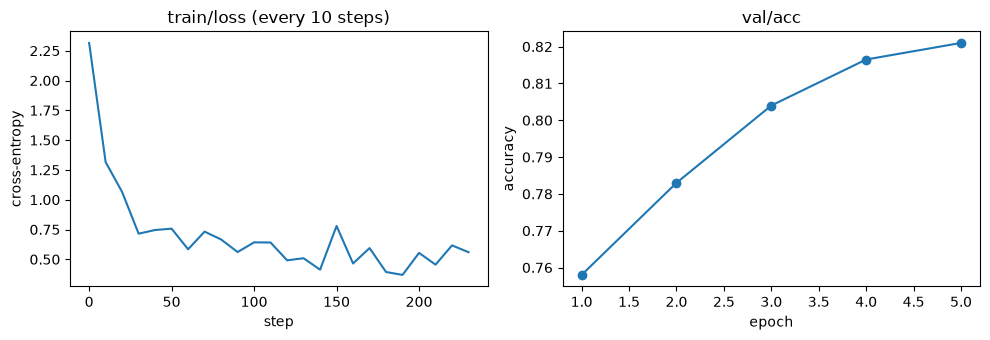

In [8]:
class MLP(nn.Module):
    def __init__(self, hidden_units=256, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(nn.Flatten(), nn.Linear(28 * 28, hidden_units), nn.ReLU(), nn.Dropout(dropout),
                                 nn.Linear(hidden_units, 10))

    def forward(self, x):
        return self.net(x)


mlp_config = {"model": "mlp", "hidden_units": 256, "dropout": 0.2, "lr": 1e-3, "batch_size": 128, "epochs": 5, "log_every": 10}
torch.manual_seed(SEED)
history_local = {"step": [], "train/loss": [], "epoch": [], "val/loss": [], "val/acc": []}

with wandb.init(project=PROJECT, name="mlp-train", job_type="train", config=mlp_config, tags=["mlp"]) as run:
    cfg = run.config
    mlp = MLP(cfg.hidden_units, cfg.dropout).to(device)
    mlp_optimizer = torch.optim.Adam(mlp.parameters(), lr=cfg.lr)
    loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=cfg.batch_size, shuffle=True, generator=torch.Generator().manual_seed(SEED))
    run.watch(mlp, log="all", log_freq=20)
    run.define_metric("val/acc", summary="max")
    started, step = time.perf_counter(), 0
    for epoch in range(1, cfg.epochs + 1):
        for xb, yb in loader:
            loss = nn.functional.cross_entropy(mlp(xb), yb)
            mlp_optimizer.zero_grad()
            loss.backward()
            mlp_optimizer.step()
            if step % cfg.log_every == 0:
                run.log({"train/loss": loss.item()}, step=step)
                history_local["step"].append(step)
                history_local["train/loss"].append(loss.item())
            step += 1
        val_loss, val_acc = evaluate(mlp, X_va, y_va)
        run.log({"val/loss": val_loss, "val/acc": val_acc, "epoch": epoch}, step=step)
        history_local["epoch"].append(epoch)
        history_local["val/loss"].append(val_loss)
        history_local["val/acc"].append(val_acc)
        print(f"epoch {epoch} | val loss {val_loss:.4f} | val acc {val_acc:.4f}")
    run.unwatch(mlp)
    run.summary["train_seconds"] = time.perf_counter() - started
    mlp_summary_before_finish = {"val/acc": dict(run.summary["val/acc"]), "val/loss": run.summary["val/loss"], "epoch": run.summary["epoch"]}
    mlp_run_id, mlp_dir = run.id, Path(run.dir).parent

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(history_local["step"], history_local["train/loss"])
axes[0].set(xlabel="step", ylabel="cross-entropy", title="train/loss (every 10 steps)")
axes[1].plot(history_local["epoch"], history_local["val/acc"], marker="o")
axes[1].set(xlabel="epoch", ylabel="accuracy", title="val/acc")
plt.tight_layout()
plt.show()

### ✍️ Your Turn

Write `accuracy_from_logits(logits, labels)` that returns the fraction (a Python `float`) of rows where the arg-max of `logits` equals `labels`. It's the function every training loop logs.

In [9]:
def accuracy_from_logits(logits, labels):
    return None  # TODO


demo_logits = torch.tensor([[2.0, 0.1, 0.3], [0.2, 0.1, 3.0], [1.0, 2.0, 0.5], [0.0, 0.0, 1.0]])
demo_labels = torch.tensor([0, 2, 0, 2])
check("accuracy_from_logits", accuracy_from_logits(demo_logits, demo_labels), 0.75, hint="(logits.argmax(dim=1) == labels).float().mean().item()")

⏳ accuracy_from_logits: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def accuracy_from_logits(logits, labels):
    return (logits.argmax(dim=1) == labels).float().mean().item()

demo_logits = torch.tensor([[2.0, 0.1, 0.3], [0.2, 0.1, 3.0], [1.0, 2.0, 0.5], [0.0, 0.0, 1.0]])
demo_labels = torch.tensor([0, 2, 0, 2])
check("accuracy_from_logits", accuracy_from_logits(demo_logits, demo_labels), 0.75)
```
`.item()` turns a 0-d tensor into a Python number — log numbers, not tensors that keep references to the graph or GPU memory.
</details>

> 💡 **Interview angle:** "Training loss goes down but validation accuracy is flat — what do you check in your dashboard?" — train vs val curves for overfitting, gradient histograms for vanishing/exploding gradients, the learning-rate curve, and a predictions table to see *which* examples fail (label noise, a class never predicted).

## 5. Media and Tables 🟡

W&B logs rich objects the same way as numbers:

| Object | Use it for |
|---|---|
| `wandb.Image(array_or_tensor, caption=...)` | input samples, predictions, attention maps |
| `wandb.Histogram(values)` | weight or activation distributions |
| `wandb.Table(columns=[...])` + `add_data(...)`, or `wandb.Table(dataframe=df)` | per-example predictions you can sort and filter in the UI |
| `wandb.plot.confusion_matrix(y_true=, preds=, class_names=)` | an interactive confusion matrix (stored as a table + chart spec) |

Tables are the killer feature for error analysis: log image, true label, prediction, and confidence, then sort by confidence to find the most confident mistakes.

358 validation mistakes; logged the 24 most confident ones
      class  accuracy
   Pullover     0.495
      Shirt     0.535
T-shirt/top     0.830
        Bag     0.880
      Dress     0.885
       Coat     0.895
    Sneaker     0.895
 Ankle boot     0.895
     Sandal     0.920
    Trouser     0.980
media files written: ['images', 'table']


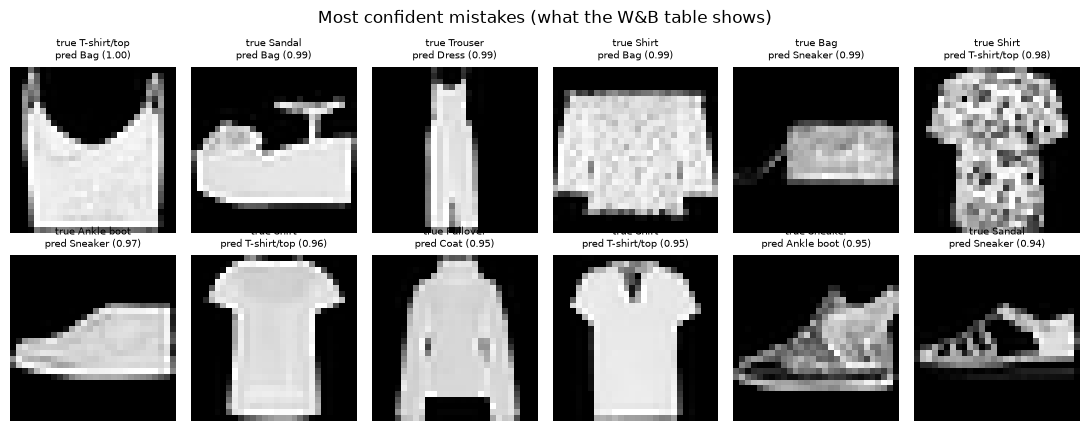

In [10]:
mlp.eval()
with torch.no_grad():
    val_logits = mlp(X_va)
val_probs = val_logits.softmax(dim=1)
val_pred = val_probs.argmax(dim=1)
val_conf = val_probs.max(dim=1).values
mistakes = torch.nonzero(val_pred != y_va).ravel()
most_confident_mistakes = mistakes[val_conf[mistakes].argsort(descending=True)][:24]

with wandb.init(project=PROJECT, name="mlp-error-analysis", job_type="eval", config={"source_run": mlp_run_id}) as run:
    samples = [wandb.Image(X_va[i, 0].numpy(), caption=CLASSES[int(y_va[i])]) for i in range(16)]
    predictions = wandb.Table(columns=["image", "true", "predicted", "confidence", "correct"])
    for i in most_confident_mistakes.tolist():
        predictions.add_data(wandb.Image(X_va[i, 0].numpy()), CLASSES[int(y_va[i])], CLASSES[int(val_pred[i])], round(float(val_conf[i]), 4), False)
    per_class = pd.DataFrame({"class": CLASSES,
                              "accuracy": [float((val_pred[y_va == c] == c).float().mean()) for c in range(len(CLASSES))]})
    run.log({
        "samples": samples,
        "first_layer_weights": wandb.Histogram(mlp.net[1].weight.detach().numpy().ravel()),
        "most_confident_mistakes": predictions,
        "per_class_accuracy": wandb.Table(dataframe=per_class),
        "confusion_matrix": wandb.plot.confusion_matrix(y_true=y_va.tolist(), preds=val_pred.tolist(), class_names=CLASSES),
    })
    media_dir = Path(run.dir).parent

print(f"{len(mistakes)} validation mistakes; logged the {len(most_confident_mistakes)} most confident ones")
print(per_class.sort_values("accuracy").round(3).to_string(index=False))
print("media files written:", sorted({p.parent.name for p in (media_dir / "files" / "media").rglob("*") if p.is_file()}))

fig, axes = plt.subplots(2, 6, figsize=(11, 4.4))
for ax, i in zip(axes.ravel(), most_confident_mistakes[:12].tolist()):
    ax.imshow(X_va[i, 0], cmap="gray")
    ax.set_title(f"true {CLASSES[int(y_va[i])]}\npred {CLASSES[int(val_pred[i])]} ({val_conf[i]:.2f})", fontsize=7)
    ax.axis("off")
plt.suptitle("Most confident mistakes (what the W&B table shows)")
plt.tight_layout()
plt.show()

### ✍️ Your Turn

Build a `wandb.Table` directly from the DataFrame `per_class` (use the `dataframe=` argument) and store its column names (`table.columns`) in `table_columns`.

In [11]:
table_columns = None  # TODO
check("table_columns", table_columns, ["class", "accuracy"], hint="wandb.Table(dataframe=per_class).columns")

⏳ table_columns: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
table_columns = list(wandb.Table(dataframe=per_class).columns)
check("table_columns", table_columns, ["class", "accuracy"])
```
</details>

> 💡 **Interview angle:** "How do you do error analysis on a classifier?" — log a predictions table (input, label, prediction, confidence), sort by confidence among mistakes, look for label noise and confusable classes (here: shirts vs T-shirts vs pullovers), then fix data or add targeted augmentation.

## 6. Reading an Offline Run Back 🟡

Offline runs are stored in one file per run: `run-<id>.wandb`. It's a **log of protobuf `Record` messages** — every `config` update, `history` row, `summary` update, and `artifact` — framed in 32 KB blocks the way LevelDB's log format frames records. `wandb sync` replays exactly this file to the server.

The reader below is ~30 lines. ⚠️ This is W&B's *internal* format — perfect for learning and for verifying offline jobs, but for production use the public API (`wandb.Api().run("entity/project/id").history()`), which needs the server.

In [12]:
BLOCK_SIZE, CHUNK_HEADER = 32768, 7                 # 4-byte CRC, 2-byte length, 1-byte chunk type
FULL, FIRST, MIDDLE, LAST = 1, 2, 3, 4


def iter_wandb_records(path):
    data = Path(path).read_bytes()
    if data[:4] != b":W&B":
        raise ValueError(f"{path} is not a .wandb file")
    pos, pending = 7, b""                           # 7-byte file header: ':W&B' + magic + version
    while pos + CHUNK_HEADER <= len(data):
        room = BLOCK_SIZE - pos % BLOCK_SIZE
        if room < CHUNK_HEADER:                     # block trailer padding
            pos += room
            continue
        _crc, length, kind = struct.unpack("<IHB", data[pos:pos + CHUNK_HEADER])
        if length == 0 and kind == 0:               # zero padding at the end of a block
            pos += room
            continue
        chunk = data[pos + CHUNK_HEADER:pos + CHUNK_HEADER + length]
        pos += CHUNK_HEADER + length
        if kind == FULL:
            payload = chunk
        elif kind == FIRST:
            pending = chunk
            continue
        elif kind == MIDDLE:
            pending += chunk
            continue
        elif kind == LAST:
            payload, pending = pending + chunk, b""
        else:
            continue
        record = wandb_pb.Record()
        record.ParseFromString(payload)
        yield record


def _key(item):
    return item.key or "/".join(item.nested_key)


def read_offline_run(run_dir, timeout=30):
    """Parse an offline run folder into config, history rows, final summary, and artifacts."""
    run_file = next(Path(run_dir).glob("run-*.wandb"))
    deadline = time.time() + timeout
    while True:                                     # the background writer may need a moment after finish()
        records = list(iter_wandb_records(run_file))
        complete = any(r.WhichOneof("record_type") == "exit" for r in records)
        if complete or time.time() > deadline:
            break
        time.sleep(0.5)
    run = {"complete": complete, "config": {}, "history": [], "summary": {}, "artifacts": [], "record_counts": {}}
    for r in records:
        kind = r.WhichOneof("record_type")
        run["record_counts"][kind] = run["record_counts"].get(kind, 0) + 1
        if kind == "run":
            run.update(run_id=r.run.run_id, project=r.run.project, name=r.run.display_name)
            updates = r.run.config.update
        elif kind == "config":
            updates = r.config.update
        else:
            updates = []
        for u in updates:
            if u.key and not u.key.startswith("_"):
                run["config"][u.key] = json.loads(u.value_json)
        if kind == "history":
            run["history"].append({_key(i): json.loads(i.value_json) for i in r.history.item})
        elif kind == "summary":
            for u in r.summary.update:
                run["summary"][_key(u)] = json.loads(u.value_json)
        elif kind == "artifact":
            run["artifacts"].append({"name": r.artifact.name, "type": r.artifact.type, "aliases": list(r.artifact.aliases),
                                     "digest": r.artifact.digest, "metadata": json.loads(r.artifact.metadata or "{}"),
                                     "files": {e.path: {"digest": e.digest, "size": e.size} for e in r.artifact.manifest.contents}})
    return run


mlp_logged = read_offline_run(mlp_dir)
print("complete:", mlp_logged["complete"], "| run:", mlp_logged["run_id"], mlp_logged["name"], "| records:", mlp_logged["record_counts"])
print("config  :", mlp_logged["config"])

train_rows = [row for row in mlp_logged["history"] if "train/loss" in row]
val_rows = [row for row in mlp_logged["history"] if "val/acc" in row]
assert [row["_step"] for row in train_rows] == history_local["step"]
assert np.allclose([row["train/loss"] for row in train_rows], history_local["train/loss"])
assert np.allclose([row["val/acc"] for row in val_rows], history_local["val/acc"])
gradient_keys = sorted({k.split("/")[1] for row in mlp_logged["history"] for k in row if k.startswith("gradients/")})
print(f"✅ {len(train_rows)} train/loss rows and {len(val_rows)} val rows match what the loop logged")
print("gradient histograms recorded for:", gradient_keys)

summary_view = {k: v for k, v in mlp_logged["summary"].items() if k in ("val/acc", "val/loss", "epoch", "train_seconds")}
print("final summary from the file:", summary_view)
assert mlp_logged["summary"]["val/acc"] == {"max": max(history_local["val/acc"])}
assert np.isclose(mlp_logged["summary"]["val/loss"], history_local["val/loss"][-1])
print("✅ summary: val/acc is the best epoch (define_metric max), val/loss is the last epoch (default)")

complete: True | run: zzqgvfh7 mlp-train | records: {'header': 1, 'run': 1, 'environment': 1, 'stats': 1, 'files': 1, 'telemetry': 7, 'metric': 1, 'summary': 60, 'history': 29, 'exit': 1}
config  : {'model': 'mlp', 'hidden_units': 256, 'dropout': 0.2, 'lr': 0.001, 'batch_size': 128, 'epochs': 5, 'log_every': 10}
✅ 24 train/loss rows and 5 val rows match what the loop logged
gradient histograms recorded for: ['net.1.bias', 'net.1.weight', 'net.4.bias', 'net.4.weight']
final summary from the file: {'epoch': 5, 'val/loss': 0.5251844787597656, 'val/acc': {'max': 0.821}, 'train_seconds': 0.42473987500125077}
✅ summary: val/acc is the best epoch (define_metric max), val/loss is the last epoch (default)


### ✍️ Your Turn

Using `read_offline_run(summary_dir)` (the bumpy run from section 3), collect the `val/acc` values from its history rows **in order** into a list `acc_from_file`.

In [13]:
acc_from_file = None  # TODO
check("acc_from_file", acc_from_file, val_acc_by_epoch, hint="[row['val/acc'] for row in read_offline_run(summary_dir)['history'] if 'val/acc' in row]")

⏳ acc_from_file: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
acc_from_file = [row["val/acc"] for row in read_offline_run(summary_dir)["history"] if "val/acc" in row]
check("acc_from_file", acc_from_file, val_acc_by_epoch)
```
</details>

> 💡 **Interview angle:** "Your cluster has no internet — can you still use W&B?" — yes: `WANDB_MODE=offline` writes a transaction log per run, and a job with network access runs `wandb sync` later; or run the self-hosted W&B server inside the network and point clients at it with `WANDB_BASE_URL`.

## 7. Artifacts and Lineage 🟡

An **artifact** is a named, typed, versioned bundle of files: `fashion-mnist-subset:v0`, `mlp-classifier:v3`. W&B hashes every file (MD5, stored base64) so identical content isn't stored twice, and records **lineage**:

```
data-prep run ──produces──► fashion-mnist-subset:v0 ──used by──► train run ──produces──► mlp-classifier:v0 (@best)
```

The correct recipe: **write the file, close it, then** `artifact.add_file(path)`, then `run.log_artifact(artifact, aliases=[...])`. (Pitfall 2 shows the truncated artifact you get otherwise.) Consuming an artifact — `run.use_artifact("name:alias")` and `.download()` — talks to the server, so it only works online.

In [14]:
ARTIFACT_DIR = OUTPUT_DIR / "wandb_files"
ARTIFACT_DIR.mkdir(exist_ok=True)


def md5_base64(path):
    return base64.b64encode(hashlib.md5(Path(path).read_bytes()).digest()).decode()


with wandb.init(project=PROJECT, name="data-prep", job_type="data-prep") as run:
    dataset_path = ARTIFACT_DIR / "fashion_mnist_subset.npz"
    np.savez_compressed(dataset_path, train_idx=train_idx, val_idx=val_idx, test_idx=test_idx)   # np.savez closes the file for us
    dataset_artifact = wandb.Artifact("fashion-mnist-subset", type="dataset",
                                      description="Stratified FashionMNIST indices: 600/200/200 per class",
                                      metadata={"train": len(train_idx), "val": len(val_idx), "test": len(test_idx), "seed": SEED})
    dataset_artifact.add_file(str(dataset_path))
    run.log_artifact(dataset_artifact)
    try:
        run.use_artifact("fashion-mnist-subset:latest")
    except Exception as err:                           # offline: lineage "used by" edges need the server
        print(f"use_artifact offline → {type(err).__name__}: {err}")
    data_prep_dir = Path(run.dir).parent

with wandb.init(project=PROJECT, name="mlp-model-upload", job_type="train", config={"source_run": mlp_run_id}) as run:
    checkpoint_path = ARTIFACT_DIR / "mlp_state_dict.pt"
    torch.save(mlp.state_dict(), checkpoint_path)      # torch.save opens and closes the file itself
    model_artifact = wandb.Artifact("mlp-classifier", type="model",
                                    metadata={"val_acc": max(history_local["val/acc"]), **mlp_config})
    model_artifact.add_file(str(checkpoint_path))
    run.log_artifact(model_artifact, aliases=["best", f"epoch-{mlp_config['epochs']}"])
    model_upload_dir = Path(run.dir).parent

for folder in (data_prep_dir, model_upload_dir):
    for art in read_offline_run(folder)["artifacts"]:
        files = {name: info["size"] for name, info in art["files"].items()}
        print(f"{art['name']} ({art['type']}) aliases={art['aliases']} files={files} metadata keys={sorted(art['metadata'])}")

recorded = read_offline_run(model_upload_dir)["artifacts"][0]["files"]["mlp_state_dict.pt"]
print("digest in the run file:", recorded["digest"], "| our MD5 of the checkpoint:", md5_base64(checkpoint_path),
      "| match:", recorded["digest"] == md5_base64(checkpoint_path))

use_artifact offline → TypeError: Cannot use artifact when in offline mode.


fashion-mnist-subset (dataset) aliases=['latest'] files={'fashion_mnist_subset.npz': 16734} metadata keys=['seed', 'test', 'train', 'val']
mlp-classifier (model) aliases=['latest', 'best', 'epoch-5'] files={'mlp_state_dict.pt': 816739} metadata keys=['batch_size', 'dropout', 'epochs', 'hidden_units', 'log_every', 'lr', 'model', 'val_acc']
digest in the run file: fIP5ezkdOqCtOHKBREAsWA== | our MD5 of the checkpoint: fIP5ezkdOqCtOHKBREAsWA== | match: True


**Online only (guarded):** with an account, the training run would declare its input and fetch it, and W&B would draw the lineage graph.

In [15]:
if os.environ.get("WANDB_API_KEY") and os.environ.get("WANDB_MODE") == "online":
    with wandb.init(project=PROJECT, name="lineage-online", job_type="train") as run:
        dataset = run.use_artifact("fashion-mnist-subset:latest")          # records the "used by" edge
        local_folder = dataset.download(root=str(OUTPUT_DIR / "downloaded_artifact"))
        print("downloaded to", local_folder, "| files:", sorted(os.listdir(local_folder)))
else:
    print("⏭️ Skipped: needs WANDB_API_KEY and WANDB_MODE=online (run `wandb login`). Offline, artifacts are recorded and "
          "hashed locally (shown above) and uploaded with their lineage by `wandb sync`.")

⏭️ Skipped: needs WANDB_API_KEY and WANDB_MODE=online (run `wandb login`). Offline, artifacts are recorded and hashed locally (shown above) and uploaded with their lineage by `wandb sync`.


### ✍️ Your Turn

W&B identifies file contents by a base64-encoded MD5 digest. Compute it for `dataset_path` **without** using `md5_base64` (use `hashlib` and `base64` directly) and store it in `dataset_digest`.

In [16]:
dataset_digest = None  # TODO
check("dataset_digest", dataset_digest, dataset_artifact.manifest.entries["fashion_mnist_subset.npz"].digest,
      hint="base64.b64encode(hashlib.md5(bytes).digest()).decode()")

⏳ dataset_digest: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
dataset_digest = base64.b64encode(hashlib.md5(dataset_path.read_bytes()).digest()).decode()
check("dataset_digest", dataset_digest, dataset_artifact.manifest.entries["fashion_mnist_subset.npz"].digest)
```
Content hashing is why re-logging an unchanged dataset doesn't create a new version, and why a changed file does.
</details>

> 💡 **Interview angle:** "Six months later, which data trained the model in production?" — follow lineage: the model artifact version → the run that produced it (config, code, commit) → the dataset artifact version it used. Without artifacts you're guessing from S3 paths.

## 8. Offline, Disabled, and Syncing Later 🟢

| Mode | What happens | Typical use |
|---|---|---|
| `online` (default after `wandb login`) | streams to the W&B server live | normal work |
| `offline` | writes `offline-run-*` folders locally | air-gapped clusters, flaky networks, this notebook |
| `disabled` | every call is a no-op; nothing is written | unit tests, CI, debugging |

Set it with `WANDB_MODE` or `wandb.init(mode=...)`. Later, upload offline runs with `wandb sync <run folder>` (`--dry-run` shows what would be uploaded without needing a key).

Other environment variables you'll meet:

| Variable | Meaning |
|---|---|
| `WANDB_API_KEY` | authentication (prefer `wandb login`, never commit it) |
| `WANDB_BASE_URL` | the server address for **self-hosted W&B** (e.g. `https://wandb.mycompany.com`) |
| `WANDB_ENTITY`, `WANDB_PROJECT` | defaults for `wandb.init` |
| `WANDB_DIR` | where run folders are written |
| `WANDB_SILENT` | hide console output |

In [17]:
run_folders = lambda: sorted(p.name for p in (WANDB_HOME / "wandb").glob("*run-*"))
before = run_folders()
disabled_run = wandb.init(project=PROJECT, name="disabled-demo", mode="disabled")
disabled_run.log({"loss": 0.123})
disabled_run.summary["note"] = "nothing is saved"
disabled_run.finish()
print(f"disabled run type: {type(disabled_run).__name__} | new run folders created: {len(run_folders()) - len(before)}")

wandb_cli = shutil.which("wandb") or str(Path(sys.executable).parent / "wandb")
quiet_env = {k: v for k, v in os.environ.items() if k != "WANDB_SILENT"}
result = subprocess.run([wandb_cli, "sync", "--dry-run", str(mlp_dir)], capture_output=True, text=True, env=quiet_env, timeout=120)
print(f"\n$ wandb sync --dry-run {mlp_dir.relative_to(Path.cwd())}\n" + (result.stdout + result.stderr).strip().replace(str(Path.cwd()) + "/", ""))

disabled run type: NoopRun | new run folders created: 0



$ wandb sync --dry-run _outputs/wandb_home/wandb/offline-run-20260913_201339-zzqgvfh7
wandb: Would sync 1 run(s):
wandb:   _outputs/wandb_home/wandb/offline-run-20260913_201339-zzqgvfh7/run-zzqgvfh7.wandb


> 💡 **Interview angle:** "How do you keep experiment tracking out of your unit tests?" — `WANDB_MODE=disabled` (or `mode="disabled"`) turns every call into a no-op, so the same training code runs in CI without network access or credentials.

## 9. Sweeps: Search Strategies and Early Termination 🔴

A **sweep** is a hyperparameter search coordinated by W&B:

```
  sweep config ──wandb.sweep()──► controller (on the W&B server)
                                       │  "try lr=0.003, hidden=128"
                    ┌──────────────────┼──────────────────┐
                 agent 1            agent 2            agent 3      (wandb.agent / `wandb agent <id>` on any machine)
                 run train()        run train()        run train()  → each reports val/acc back
```

| `method` | How the next configuration is chosen | Good for |
|---|---|---|
| `grid` | every combination of discrete values | tiny spaces |
| `random` | independent random samples from each distribution | strong default; parallelizes perfectly |
| `bayes` | a surrogate model of metric-vs-config picks promising points | expensive runs, few continuous parameters |

**Early termination with Hyperband** stops weak runs at checkpoints called *brackets*. W&B's docs give two ways to define them: from `min_iter` and `eta` — brackets at `min_iter`, `min_iter·eta`, `min_iter·eta²`, … (their example: `min_iter=3, eta=3` → `[3, 9, 27, 81]`) — or from `max_iter`, `eta`, and `s` (their example: `max_iter=27, eta=3, s=2` → `[9, 3]`). An "iteration" is one logged value of the target metric, so log it once per epoch.

⚠️ The controller lives on the W&B server: `wandb.sweep()` needs an API key and network access (Pitfall 4 shows the offline error). Below, the configuration and the bracket math run locally; the actual sweep is in a guarded cell.

In [18]:
sweep_config = {
    "name": "mlp-fashion-sweep",
    "method": "bayes",
    "metric": {"name": "val/acc", "goal": "maximize"},
    "parameters": {
        "lr": {"distribution": "log_uniform_values", "min": 1e-4, "max": 1e-1},
        "hidden_units": {"values": [64, 128, 256]},
        "dropout": {"distribution": "uniform", "min": 0.0, "max": 0.5},
        "batch_size": {"values": [64, 128]},
        "epochs": {"value": 8},
    },
    "early_terminate": {"type": "hyperband", "min_iter": 1, "eta": 2},
}


def hyperband_brackets_from_min_iter(min_iter, eta, count):
    return [min_iter * eta**k for k in range(count)]


def hyperband_brackets_from_max_iter(max_iter, eta, s):
    return [max_iter // eta**k for k in range(1, s + 1)]


print("docs example (min_iter=3, eta=3):", hyperband_brackets_from_min_iter(3, 3, 4))
print("docs example (max_iter=27, eta=3, s=2):", hyperband_brackets_from_max_iter(27, 3, 2))
print("our config (min_iter=1, eta=2), within 8 epochs:", [b for b in hyperband_brackets_from_min_iter(1, 2, 5) if b <= 8])

docs example (min_iter=3, eta=3): [3, 9, 27, 81]
docs example (max_iter=27, eta=3, s=2): [9, 3]
our config (min_iter=1, eta=2), within 8 epochs: [1, 2, 4, 8]


To make the search space concrete, here is **our own** sampler for the `random` method (a teaching re-implementation, not W&B's code): each parameter is drawn independently from its distribution.

In [19]:
def sample_config(parameters, generator):
    config = {}
    for name, spec in parameters.items():
        if "value" in spec:
            config[name] = spec["value"]
        elif "values" in spec:
            config[name] = spec["values"][generator.integers(len(spec["values"]))]
        elif spec["distribution"] == "uniform":
            config[name] = float(generator.uniform(spec["min"], spec["max"]))
        elif spec["distribution"] == "log_uniform_values":
            config[name] = float(np.exp(generator.uniform(np.log(spec["min"]), np.log(spec["max"]))))
        else:
            raise ValueError(f"unsupported distribution {spec['distribution']}")
    return config


sampler_rng = np.random.default_rng(SEED)
samples = pd.DataFrame([sample_config(sweep_config["parameters"], sampler_rng) for _ in range(6)])
print(samples.round(4).to_string(index=False))
print(f"\nlog-uniform lr: median of 2,000 draws = {np.median([sample_config({'lr': sweep_config['parameters']['lr']}, sampler_rng)['lr'] for _ in range(2000)]):.4f} "
      f"(geometric midpoint {np.sqrt(1e-4 * 1e-1):.4f}) — equal time is spent on each order of magnitude")


def train_for_sweep():
    """What every agent runs: read the chosen values from run.config, train, log the target metric each epoch."""
    with wandb.init() as run:
        cfg = run.config
        model = MLP(cfg.hidden_units, cfg.dropout)
        optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr)
        loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=cfg.batch_size, shuffle=True)
        for epoch in range(1, cfg.epochs + 1):
            for xb, yb in loader:
                loss = nn.functional.cross_entropy(model(xb), yb)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            val_loss, val_acc = evaluate(model, X_va, y_va)
            run.log({"val/acc": val_acc, "val/loss": val_loss, "epoch": epoch})   # one value per epoch = one Hyperband iteration

    lr  hidden_units  dropout  batch_size  epochs
0.0210           128   0.4293          64       8
0.0124            64   0.4878          64       8
0.0192           256   0.0641         128       8
0.0022           128   0.4634          64       8
0.0085           128   0.2217         128       8
0.0005            64   0.0319         128       8

log-uniform lr: median of 2,000 draws = 0.0030 (geometric midpoint 0.0032) — equal time is spent on each order of magnitude


In [20]:
if os.environ.get("WANDB_API_KEY") and os.environ.get("WANDB_MODE") == "online":
    sweep_id = wandb.sweep(sweep_config, project=PROJECT)
    wandb.agent(sweep_id, function=train_for_sweep, count=6)
    print("sweep finished:", sweep_id)
else:
    print("⏭️ Skipped: sweeps need the W&B server (WANDB_API_KEY + WANDB_MODE=online). The config, bracket math, and training "
          "function above are ready — after `wandb login`, set WANDB_MODE=online and re-run this cell.")

⏭️ Skipped: sweeps need the W&B server (WANDB_API_KEY + WANDB_MODE=online). The config, bracket math, and training function above are ready — after `wandb login`, set WANDB_MODE=online and re-run this cell.


### ✍️ Your Turn

Using `hyperband_brackets_from_min_iter`, compute the brackets for `min_iter=2`, `eta=3` and **keep only those ≤ 50** (try 5 candidates). Store the list in `my_brackets`.

In [21]:
my_brackets = None  # TODO
check("my_brackets", my_brackets, [2, 6, 18], hint="[b for b in hyperband_brackets_from_min_iter(2, 3, 5) if b <= 50]")

⏳ my_brackets: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
my_brackets = [b for b in hyperband_brackets_from_min_iter(2, 3, 5) if b <= 50]
check("my_brackets", my_brackets, [2, 6, 18])
```
The next bracket, 54, is beyond 50 epochs — runs that survive to 18 simply finish.
</details>

> 💡 **Interview angle:** "Random or Bayesian search?" — random search is embarrassingly parallel and hard to beat when only a few hyperparameters matter (Bergstra & Bengio, 2012); Bayesian optimization needs fewer trials for expensive, low-dimensional problems but is sequential by nature. Add Hyperband-style early stopping to either, and remember it can kill slow starters.

## 10. W&B vs MLflow: A Decision Guide 🟢

| Question | Weights & Biases | MLflow |
|---|---|---|
| Hosting | managed SaaS by default; self-managed W&B Server needs a license | fully open source; self-host anywhere, or managed on Databricks / SageMaker / Azure ML |
| Strongest at | live DL dashboards, media and tables, sweeps, reports, collaboration | model packaging, registry aliases, serving, evaluation, tracing, open formats |
| Hyperparameter search | built-in sweeps (grid / random / bayes + Hyperband) | none built in — pair with Optuna, Ray Tune, or Hyperopt |
| Model registry | W&B Registry (artifact versions + aliases) | Model Registry (versions + aliases, `models:/name@alias`) |
| Serving | not a serving platform | `mlflow models serve`, `build-docker`, many integrations |
| LLM tracing | W&B Weave | MLflow Tracing |
| Data governance | your data leaves your network unless self-managed | stays wherever you host it |

Many teams use **both**: W&B for research-time dashboards and sweeps, MLflow (or a cloud registry) for the production model lifecycle. The concepts map one-to-one — below we log the *same* curve to both and read both back.

In [22]:
os.environ["MLFLOW_DISABLE_AGENT_HINT"] = "1"          # MLflow 3.16 prints a hint for AI coding assistants on import
import logging

import mlflow

logging.getLogger("mlflow").setLevel(logging.WARNING)
mlflow_store = OUTPUT_DIR / "mlflow_compare"
shutil.rmtree(mlflow_store, ignore_errors=True)
mlflow_store.mkdir()
mlflow.set_tracking_uri(f"sqlite:///{mlflow_store / 'mlflow.db'}")
mlflow.set_experiment("wandb-vs-mlflow")

curve = history_local["val/acc"]                         # the real validation curve from section 4
with wandb.init(project=PROJECT, name="same-curve", config={"source": "section 4"}) as wb_run, \
        mlflow.start_run(run_name="same-curve") as ml_run:
    mlflow.log_params({"source": "section 4"})
    for epoch, acc in enumerate(curve, start=1):
        wb_run.log({"val_acc": acc}, step=epoch)
        mlflow.log_metric("val_acc", acc, step=epoch)
    same_curve_dir = Path(wb_run.dir).parent

wb_back = read_offline_run(same_curve_dir)
wb_points = [(row["_step"], row["val_acc"]) for row in wb_back["history"] if "val_acc" in row]
ml_points = [(m.step, m.value) for m in mlflow.MlflowClient().get_metric_history(ml_run.info.run_id, "val_acc")]
print("W&B history   :", [(s, round(v, 4)) for s, v in wb_points])
print("MLflow history:", [(s, round(v, 4)) for s, v in sorted(ml_points)])
print("identical curves:", wb_points == sorted(ml_points),
      "| W&B summary (last):", round(wb_back["summary"]["val_acc"], 4),
      "| MLflow latest:", round(mlflow.get_run(ml_run.info.run_id).data.metrics["val_acc"], 4))
print("config / params:", wb_back["config"], "|", mlflow.get_run(ml_run.info.run_id).data.params)

W&B history   : [(1, 0.758), (2, 0.783), (3, 0.804), (4, 0.8165), (5, 0.821)]
MLflow history: [(1, 0.758), (2, 0.783), (3, 0.804), (4, 0.8165), (5, 0.821)]
identical curves: True | W&B summary (last): 0.821 | MLflow latest: 0.821
config / params: {'source': 'section 4'} | {'source': 'section 4'}


> 💡 **Interview angle:** "Which tracker would you pick?" — say what drives it: data-residency rules and a need for serving/registry favour self-hosted MLflow; a research team doing many GPU runs, sweeps, and shared reports favours W&B. Mention you've used the one-to-one concept mapping (config↔params, log↔log_metric, summary↔latest metric, artifacts↔artifacts).

## 🔧 Build It From Scratch

The two rules that confuse people most are **how steps work** and **what the summary shows**. Let's re-implement both in a tiny logger and prove it matches a real offline W&B run value for value.

Rules we implement:
1. `log(metrics)` with no step → added to the open row (or a new row at the next step if none is open), and that row is **committed**.
2. `log(metrics, step=s)` with `s` equal to the current row's step → merged into that row; greater → the current row is committed and a new one starts; **smaller → dropped**.
3. Summary per key: the **last** value, unless `define_metric(key, summary="max" | "min" | "mean" | "last" | combinations)` was called, in which case it's a dict of those aggregates over accepted values.
4. `summary[key] = value` overrides everything.

In [23]:
class MiniLogger:
    AGGREGATES = {"min": min, "max": max, "mean": lambda v: sum(v) / len(v), "last": lambda v: v[-1]}

    def __init__(self):
        self.history, self.dropped = [], []
        self._row, self._row_step, self._next_auto = {}, None, 0
        self._values, self._definitions, self._overrides = {}, {}, {}

    def define_metric(self, name, summary):
        self._definitions[name] = summary.split(",")

    def _commit(self):
        if self._row_step is not None:
            self.history.append({"_step": self._row_step, **self._row})
            self._next_auto = self._row_step + 1
            self._row, self._row_step = {}, None

    def log(self, metrics, step=None):
        if step is None:                                           # rule 1: merge into the open row (or start one), then commit
            if self._row_step is None:
                self._row_step = self._next_auto
            self._row.update(metrics)
            for key, value in metrics.items():
                self._values.setdefault(key, []).append(value)
            self._commit()
            return
        if self._row_step is not None and step < self._row_step or self._row_step is None and step < self._next_auto:
            self.dropped.append((step, metrics))                   # rule 2: steps must not go backwards
            return
        elif self._row_step is not None and step > self._row_step:
            self._commit()
        self._row_step = step
        self._row.update(metrics)
        for key, value in metrics.items():
            self._values.setdefault(key, []).append(value)

    def finish(self):
        self._commit()

    @property
    def summary(self):
        out = {}
        for key, values in self._values.items():
            if key in self._definitions:
                out[key] = {agg: self.AGGREGATES[agg](values) for agg in self._definitions[key]}
            else:
                out[key] = values[-1]
        return {**out, **self._overrides}

    def __setitem__(self, key, value):
        self._overrides[key] = value


events = [                                        # a controlled, hand-written sequence that exercises every rule
    ({"loss": 0.90, "acc": 0.50, "grad_norm": 3.0}, 0),
    ({"loss": 0.60, "grad_norm": 2.0}, 1),
    ({"acc": 0.70}, 1),                           # same step → merged
    ({"loss": 0.80, "acc": 0.65, "grad_norm": 2.5}, 2),
    ({"loss": 0.10, "acc": 0.99, "grad_norm": 9.0}, 1),   # step went backwards → dropped
    ({"loss": 0.50, "acc": 0.72, "grad_norm": 1.0}, 3),
    ({"lr": 0.001}, None),                        # no step → merged into the open row (step 3), which is committed
]
definitions = {"acc": "max", "loss": "min,last", "grad_norm": "mean"}

mini = MiniLogger()
with wandb.init(project=PROJECT, name="mini-logger-reference") as run:
    for name, summary in definitions.items():
        run.define_metric(name, summary=summary)
        mini.define_metric(name, summary)
    for metrics, step in events:
        run.log(metrics, step=step) if step is not None else run.log(metrics)
        mini.log(metrics, step=step)
    run.summary["best_epoch"] = 3
    mini["best_epoch"] = 3
    reference_dir = Path(run.dir).parent
mini.finish()

reference = read_offline_run(reference_dir)
wandb_history = [{k: v for k, v in row.items() if not k.startswith("_") or k == "_step"} for row in reference["history"]]
wandb_summary = {k: v for k, v in reference["summary"].items() if not k.startswith("_")}
print("MiniLogger history:", mini.history)
print("W&B history       :", wandb_history)
print("MiniLogger summary:", mini.summary)
print("W&B summary       :", wandb_summary)
print("dropped by MiniLogger:", mini.dropped)
assert mini.history == wandb_history
assert mini.summary.keys() == wandb_summary.keys()
for key, value in wandb_summary.items():
    ours = mini.summary[key]
    assert (ours.keys() == value.keys() and all(np.isclose(ours[a], value[a]) for a in value)) if isinstance(value, dict) else np.isclose(ours, value)
print("✅ MiniLogger reproduces W&B's step merging, dropped out-of-order step, and last/min/max/mean/override summaries")

MiniLogger history: [{'_step': 0, 'loss': 0.9, 'acc': 0.5, 'grad_norm': 3.0}, {'_step': 1, 'loss': 0.6, 'grad_norm': 2.0, 'acc': 0.7}, {'_step': 2, 'loss': 0.8, 'acc': 0.65, 'grad_norm': 2.5}, {'_step': 3, 'loss': 0.5, 'acc': 0.72, 'grad_norm': 1.0, 'lr': 0.001}]
W&B history       : [{'loss': 0.9, 'acc': 0.5, 'grad_norm': 3, '_step': 0}, {'loss': 0.6, 'grad_norm': 2, 'acc': 0.7, '_step': 1}, {'grad_norm': 2.5, '_step': 2, 'loss': 0.8, 'acc': 0.65}, {'_step': 3, 'loss': 0.5, 'acc': 0.72, 'grad_norm': 1, 'lr': 0.001}]
MiniLogger summary: {'loss': {'min': 0.5, 'last': 0.5}, 'acc': {'max': 0.72}, 'grad_norm': {'mean': 2.125}, 'lr': 0.001, 'best_epoch': 3}
W&B summary       : {'loss': {'min': 0.5, 'last': 0.5}, 'acc': {'max': 0.72}, 'grad_norm': {'mean': 2.125}, 'lr': 0.001, 'best_epoch': 3}
dropped by MiniLogger: [(1, {'loss': 0.1, 'acc': 0.99, 'grad_norm': 9.0})]
✅ MiniLogger reproduces W&B's step merging, dropped out-of-order step, and last/min/max/mean/override summaries


## ⚠️ Common Pitfalls

### ❌ Pitfall 1 — Calling `wandb.init` again while a run is active

In a notebook, a second `wandb.init()` **silently finishes the first run** and starts a new one (in a plain script it returns the *same* run instead). Code that still holds the first `run` object then fails.

In [24]:
first = wandb.init(project=PROJECT, name="pitfall-first")
first.log({"loss": 1.0})
second = wandb.init(project=PROJECT, name="pitfall-second")          # ❌ first run is still "active"
print("❌ second init returned a new run:", second is not first, f"({first.id} → {second.id})")
try:
    first.log({"loss": 0.5})
except Exception as err:
    print(f"❌ logging to the first run now fails: {type(err).__name__}: {str(err)[:80]}")
second.finish()

for config in ({"lr": 0.1}, {"lr": 0.01}):                           # ✅ one `with` block per run
    with wandb.init(project=PROJECT, name=f"pitfall-lr-{config['lr']}", config=config) as run:
        run.log({"loss": 1.0})
print("✅ each run opened and closed by its own with-block")

❌ second init returned a new run: True (p6gdqrmz → utxacvc4)
❌ logging to the first run now fails: UsageError: Run (p6gdqrmz) is finished. The call to `log` will be ignored. Please make sure 


✅ each run opened and closed by its own with-block


### ❌ Pitfall 2 — Adding a file to an artifact before it is closed

Python buffers writes (about 8 KB at a time). If you `add_file` while the file is still open, W&B hashes and stages what's on disk *so far* — for a small file that can be nothing at all, for a big one a truncated tail.

In [25]:
import pickle

from sklearn.linear_model import LogisticRegression

small_model = LogisticRegression().fit([[0.0], [1.0], [2.0], [3.0]], [0, 0, 1, 1])     # a tiny model → a file smaller than the buffer
open_file = open(ARTIFACT_DIR / "model_unclosed.pkl", "wb")
pickle.dump(small_model, open_file)                                 # ❌ bytes still sitting in Python's buffer
bad_artifact = wandb.Artifact("pitfall-unclosed", type="model")
bad_artifact.add_file(str(ARTIFACT_DIR / "model_unclosed.pkl"))
open_file.close()
print(f"❌ artifact recorded {bad_artifact.manifest.entries['model_unclosed.pkl'].size} bytes; "
      f"the finished file has {(ARTIFACT_DIR / 'model_unclosed.pkl').stat().st_size} bytes")

with open(ARTIFACT_DIR / "model_closed.pkl", "wb") as f:            # ✅ the with-block closes (and flushes) the file
    pickle.dump(small_model, f)
good_artifact = wandb.Artifact("pitfall-closed", type="model")
good_artifact.add_file(str(ARTIFACT_DIR / "model_closed.pkl"))
print(f"✅ artifact recorded {good_artifact.manifest.entries['model_closed.pkl'].size} bytes = file size "
      f"{(ARTIFACT_DIR / 'model_closed.pkl').stat().st_size}")

❌ artifact recorded 0 bytes; the finished file has 712 bytes
✅ artifact recorded 712 bytes = file size 712


### ❌ Pitfall 3 — Letting the step go backwards

Common when you log train metrics with a global batch step and validation metrics with the epoch number. Every row whose step is smaller than the current one is **silently dropped**.

In [26]:
with wandb.init(project=PROJECT, name="pitfall-steps") as run:
    for batch_step in range(0, 300, 100):
        run.log({"train/loss": 1 / (batch_step + 1)}, step=batch_step)    # steps 0, 100, 200
    for epoch in (1, 2):
        run.log({"val/acc": 0.8 + epoch / 100}, step=epoch)             # ❌ steps 1 and 2 < 200
    bad_steps_dir = Path(run.dir).parent
kept = [row["_step"] for row in read_offline_run(bad_steps_dir)["history"] if "val/acc" in row]
print("❌ val/acc rows that survived:", kept)

with wandb.init(project=PROJECT, name="pitfall-steps-fixed") as run:
    run.define_metric("epoch")
    run.define_metric("val/*", step_metric="epoch")                      # ✅ plot val metrics against epoch
    for batch_step in range(0, 300, 100):
        run.log({"train/loss": 1 / (batch_step + 1)}, step=batch_step)
    for epoch in (1, 2):
        run.log({"val/acc": 0.8 + epoch / 100, "epoch": epoch}, step=200 + epoch)   # global step keeps increasing
    fixed_steps_dir = Path(run.dir).parent
print("✅ val/acc rows kept:", [(row["_step"], row["epoch"]) for row in read_offline_run(fixed_steps_dir)["history"] if "val/acc" in row])

❌ val/acc rows that survived: []


✅ val/acc rows kept: [(201, 1), (202, 2)]


### ❌ Pitfall 4 — Running a sweep without the W&B server

In [27]:
if os.environ.get("WANDB_API_KEY"):
    print("An API key is set, so wandb.sweep() would create a real sweep — not running it in this pitfall demo.")
else:
    try:
        wandb.sweep(sweep_config, project=PROJECT)                          # ❌ offline, no key
    except Exception as err:
        print(f"❌ {type(err).__name__}: {err}")
    print("✅ run sweeps online after `wandb login`, or search locally with Optuna / Ray Tune (module 12)")

❌ UsageError: No API key configured. Use `wandb login` to log in.
✅ run sweeps online after `wandb login`, or search locally with Optuna / Ray Tune (module 12)


## 🏋️ Practice Exercises

Try each one before opening the solution. Run the cell: ⏳ means not attempted, ✅ means correct.

### 🟢 Exercise 1 — Build a config
Start a run with `config={"lr": 3e-4, "batch_size": 64}`, add `epochs=3` with `run.config.update`, and store `dict(run.config)` in `ex1_config` before the run ends.

In [28]:
ex1_config = None  # TODO
check("ex1_config", ex1_config, {"lr": 3e-4, "batch_size": 64, "epochs": 3}, hint="with wandb.init(project=PROJECT, config=...) as run: run.config.update({'epochs': 3})")

⏳ ex1_config: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
with wandb.init(project=PROJECT, name="ex1", config={"lr": 3e-4, "batch_size": 64}) as run:
    run.config.update({"epochs": 3})
    ex1_config = dict(run.config)
check("ex1_config", ex1_config, {"lr": 3e-4, "batch_size": 64, "epochs": 3})
```
</details>

### 🟢 Exercise 2 — Last value vs best value
Log `loss` = `0.9`, `0.5`, `0.7` (three `run.log` calls, no `define_metric`). Set `run.summary["best_loss"]` to the smallest value, then store `(run.summary["loss"], run.summary["best_loss"])` in `summary_pair`.

In [29]:
summary_pair = None  # TODO
check("summary_pair", summary_pair, (0.7, 0.5), hint="Without define_metric the summary keeps the last logged value.")

⏳ summary_pair: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
with wandb.init(project=PROJECT, name="ex2") as run:
    losses = [0.9, 0.5, 0.7]
    for value in losses:
        run.log({"loss": value})
    run.summary["best_loss"] = min(losses)
    summary_pair = (run.summary["loss"], run.summary["best_loss"])
check("summary_pair", summary_pair, (0.7, 0.5))
```
</details>

### 🟢 Exercise 3 — Find a run id from its folder
Offline run folders are named `offline-run-YYYYMMDD_HHMMSS-<run id>`. From `mlp_dir.name`, extract the run id into `parsed_run_id`.

In [30]:
parsed_run_id = None  # TODO
check("parsed_run_id", parsed_run_id, mlp_run_id, hint="The id is the text after the last '-'.")

⏳ parsed_run_id: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
parsed_run_id = mlp_dir.name.rsplit("-", 1)[-1]
check("parsed_run_id", parsed_run_id, mlp_run_id)
```
`wandb sync` and `wandb sync --id <id>` use exactly this id.
</details>

### 🟡 Exercise 4 — An artifact done right
Save the `per_class` DataFrame to `ARTIFACT_DIR / "per_class.csv"` with `to_csv` (which opens and closes the file), add it to a `wandb.Artifact("per-class-accuracy", type="evaluation")`, and store `(manifest entry size, file size on disk)` in `csv_sizes`.

In [31]:
csv_sizes = None  # TODO
expected_size = len(per_class.to_csv(index=False).encode())
check("csv_sizes", csv_sizes, (expected_size, expected_size), hint="artifact.manifest.entries['per_class.csv'].size and path.stat().st_size; use index=False")

⏳ csv_sizes: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
csv_path = ARTIFACT_DIR / "per_class.csv"
per_class.to_csv(csv_path, index=False)
evaluation_artifact = wandb.Artifact("per-class-accuracy", type="evaluation")
evaluation_artifact.add_file(str(csv_path))
csv_sizes = (evaluation_artifact.manifest.entries["per_class.csv"].size, csv_path.stat().st_size)
expected_size = len(per_class.to_csv(index=False).encode())
check("csv_sizes", csv_sizes, (expected_size, expected_size))
```
</details>

### 🟡 Exercise 5 — Best epoch from the run file
Using `read_offline_run(mlp_dir)`, find the **epoch** (the logged `epoch` value) with the highest `val/acc` and store it as an `int` in `best_epoch_from_file`.

In [32]:
best_epoch_from_file = None  # TODO
check("best_epoch_from_file", best_epoch_from_file, int(np.argmax(history_local["val/acc"])) + 1, hint="max(rows, key=lambda r: r['val/acc'])['epoch']")

⏳ best_epoch_from_file: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
val_rows_file = [row for row in read_offline_run(mlp_dir)["history"] if "val/acc" in row]
best_epoch_from_file = int(max(val_rows_file, key=lambda r: r["val/acc"])["epoch"])
check("best_epoch_from_file", best_epoch_from_file, int(np.argmax(history_local["val/acc"])) + 1)
```
</details>

### 🔴 Exercise 6 — Successive halving by hand (interview-style)
*"Explain and implement the early-stopping step inside Hyperband."* Given validation accuracy curves for six runs (a small **hand-made** example so the answer is predictable), implement `successive_halving(curves, checkpoints, eta)`: at each checkpoint epoch (1-indexed), keep the best `max(1, len(alive) // eta)` runs by their accuracy **at that epoch**; return the sorted names of the survivors.

In [33]:
def successive_halving(curves, checkpoints, eta):
    return None  # TODO


toy_curves = {
    "a": [0.50, 0.60, 0.65, 0.66], "b": [0.55, 0.58, 0.60, 0.61], "c": [0.40, 0.70, 0.75, 0.80],
    "d": [0.52, 0.53, 0.54, 0.55], "e": [0.45, 0.62, 0.70, 0.72], "f": [0.60, 0.61, 0.62, 0.63],
}
survivors = successive_halving(toy_curves, checkpoints=[1, 2], eta=2)
check("survivors", survivors, ["f"], hint="At epoch 1 keep 6//2 = 3 runs by curves[name][0]; at epoch 2 keep 3//2 = 1 by curves[name][1].")

⏳ survivors: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def successive_halving(curves, checkpoints, eta):
    alive = list(curves)
    for epoch in checkpoints:
        keep = max(1, len(alive) // eta)
        alive = sorted(alive, key=lambda name: curves[name][epoch - 1], reverse=True)[:keep]
    return sorted(alive)

toy_curves = {
    "a": [0.50, 0.60, 0.65, 0.66], "b": [0.55, 0.58, 0.60, 0.61], "c": [0.40, 0.70, 0.75, 0.80],
    "d": [0.52, 0.53, 0.54, 0.55], "e": [0.45, 0.62, 0.70, 0.72], "f": [0.60, 0.61, 0.62, 0.63],
}
survivors = successive_halving(toy_curves, checkpoints=[1, 2], eta=2)
check("survivors", survivors, ["f"])
```

Talking point: run **c** ends best (0.80) but starts worst, so aggressive early stopping kills it. Hyperband hedges by running several brackets with different starting budgets; you can also delay the first checkpoint (`min_iter`) for models that warm up slowly.
</details>

## 🚀 Mini Project: A Tracked FashionMNIST Classifier with a Versioned Model

**Goal:** train a small convolutional network (CNN) on FashionMNIST the way you would on a real team — every setting in `config`, curves and gradients logged, early stopping on validation, the best checkpoint saved as a **versioned model artifact**, error analysis in a table — then read the offline run back and draw conclusions from the logged data, and touch the test set exactly once.

**Steps:** version the data → define config and model → tracked training with early stopping → error analysis → read the run back → final test evaluation.

### Step 1 — Version the exact data as an artifact

In [34]:
PROJECT_DIR = OUTPUT_DIR / "wandb_project"
shutil.rmtree(PROJECT_DIR, ignore_errors=True)
PROJECT_DIR.mkdir()

with wandb.init(project=PROJECT, name="project-data", job_type="data-prep") as run:
    data_file = PROJECT_DIR / "fashion_mnist_splits.npz"
    np.savez_compressed(data_file, X_tr=(X_tr * 255).byte().numpy(), y_tr=y_tr.numpy(), X_va=(X_va * 255).byte().numpy(),
                        y_va=y_va.numpy(), X_te=(X_te * 255).byte().numpy(), y_te=y_te.numpy())
    data_artifact = wandb.Artifact("fashion-mnist-splits", type="dataset", description="uint8 images + labels, 600/200/200 per class",
                                   metadata={"train_per_class": np.bincount(y_tr.numpy()).tolist(), "val_size": len(y_va), "test_size": len(y_te)})
    data_artifact.add_file(str(data_file))
    run.log_artifact(data_artifact)
    data_digest = data_artifact.manifest.entries[data_file.name].digest
print(f"dataset artifact: {data_file.stat().st_size / 1e6:.1f} MB | digest {data_digest}")

dataset artifact: 4.4 MB | digest wZeQGpwqAg4U/qbxAOM9BA==


### Step 2 — Config and model

Everything that defines the experiment lives in one `config` dict, including the dataset digest (lineage even offline).

In [35]:
class SmallCNN(nn.Module):
    def __init__(self, channels=16, hidden_units=128, dropout=0.25):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, channels, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),                  # 28 → 14
            nn.Conv2d(channels, 2 * channels, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),       # 14 → 7
        )
        self.classifier = nn.Sequential(nn.Flatten(), nn.Linear(2 * channels * 7 * 7, hidden_units), nn.ReLU(),
                                        nn.Dropout(dropout), nn.Linear(hidden_units, 10))

    def forward(self, x):
        return self.classifier(self.features(x))


project_config = {"model": "small_cnn", "channels": 16, "hidden_units": 128, "dropout": 0.25, "lr": 2e-3, "weight_decay": 1e-4,
                  "batch_size": 128, "max_epochs": 10, "patience": 2, "log_every": 20, "seed": SEED, "dataset_digest": data_digest}
torch.manual_seed(SEED)
print(SmallCNN(project_config["channels"], project_config["hidden_units"], project_config["dropout"]))
print("parameters:", sum(p.numel() for p in SmallCNN().parameters()))

SmallCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.25, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)
parameters: 206922


### Step 3 — Tracked training with early stopping and a best-checkpoint artifact

In [36]:
checkpoint_file = PROJECT_DIR / "small_cnn_best.pt"
epoch_log = []

with wandb.init(project=PROJECT, name="small-cnn", job_type="train", config=project_config, tags=["cnn", "project"]) as run:
    cfg = run.config
    torch.manual_seed(cfg.seed)
    cnn = SmallCNN(cfg.channels, cfg.hidden_units, cfg.dropout)
    cnn_optimizer = torch.optim.AdamW(cnn.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(cnn_optimizer, T_max=cfg.max_epochs)
    loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=cfg.batch_size, shuffle=True, generator=torch.Generator().manual_seed(cfg.seed))
    run.watch(cnn, log="gradients", log_freq=50)
    run.define_metric("val/acc", summary="max")
    run.define_metric("val/loss", summary="min")

    best_acc, best_epoch, epochs_without_improvement, step = -1.0, 0, 0, 0
    started = time.perf_counter()
    for epoch in range(1, cfg.max_epochs + 1):
        running_correct = 0
        for xb, yb in loader:
            logits = cnn(xb)
            loss = nn.functional.cross_entropy(logits, yb)
            cnn_optimizer.zero_grad()
            loss.backward()
            cnn_optimizer.step()
            running_correct += (logits.argmax(1) == yb).sum().item()
            if step % cfg.log_every == 0:
                run.log({"train/loss": loss.item(), "train/lr": scheduler.get_last_lr()[0]}, step=step)
            step += 1
        scheduler.step()
        val_loss, val_acc = evaluate(cnn, X_va, y_va)
        train_acc = running_correct / len(X_tr)
        run.log({"val/loss": val_loss, "val/acc": val_acc, "train/acc": train_acc, "epoch": epoch}, step=step)
        epoch_log.append({"epoch": epoch, "train_acc": train_acc, "val_loss": val_loss, "val_acc": val_acc})
        if val_acc > best_acc:
            best_acc, best_epoch, epochs_without_improvement = val_acc, epoch, 0
            torch.save(cnn.state_dict(), checkpoint_file)                  # closed when torch.save returns
        else:
            epochs_without_improvement += 1
        print(f"epoch {epoch:2d} | train acc {train_acc:.4f} | val loss {val_loss:.4f} | val acc {val_acc:.4f}"
              f"{'  ← best' if best_epoch == epoch else ''}")
        if epochs_without_improvement >= cfg.patience:
            print(f"early stopping: no improvement for {cfg.patience} epochs")
            break
    run.unwatch(cnn)

    run.summary.update({"best_epoch": best_epoch, "stopped_epoch": epoch, "train_seconds": time.perf_counter() - started})
    model_artifact = wandb.Artifact("small-cnn-fashion", type="model", description="best validation checkpoint (state_dict)",
                                    metadata={"best_epoch": best_epoch, "val_acc": best_acc, "dataset_digest": data_digest, **project_config})
    model_artifact.add_file(str(checkpoint_file))
    run.log_artifact(model_artifact, aliases=["best", f"epoch-{best_epoch}"])
    cnn_run_dir = Path(run.dir).parent
print(f"best val acc {best_acc:.4f} at epoch {best_epoch}; checkpoint {checkpoint_file.stat().st_size / 1e3:.0f} kB")

epoch  1 | train acc 0.5747 | val loss 0.7248 | val acc 0.7210  ← best


epoch  2 | train acc 0.7533 | val loss 0.6334 | val acc 0.7460  ← best


epoch  3 | train acc 0.7925 | val loss 0.5476 | val acc 0.7925  ← best


epoch  4 | train acc 0.8103 | val loss 0.5009 | val acc 0.8240  ← best


epoch  5 | train acc 0.8272 | val loss 0.4702 | val acc 0.8320  ← best


epoch  6 | train acc 0.8413 | val loss 0.4445 | val acc 0.8405  ← best


epoch  7 | train acc 0.8485 | val loss 0.4309 | val acc 0.8510  ← best


epoch  8 | train acc 0.8543 | val loss 0.4249 | val acc 0.8515  ← best


epoch  9 | train acc 0.8600 | val loss 0.4170 | val acc 0.8555  ← best


epoch 10 | train acc 0.8630 | val loss 0.4153 | val acc 0.8590  ← best
best val acc 0.8590 at epoch 10; checkpoint 832 kB


### Step 4 — Error analysis on validation (with the best checkpoint)

In [37]:
best_cnn = SmallCNN(project_config["channels"], project_config["hidden_units"], project_config["dropout"])
best_cnn.load_state_dict(torch.load(checkpoint_file, weights_only=True))
best_cnn.eval()
with torch.no_grad():
    probs_va = best_cnn(X_va).softmax(1)
pred_va, conf_va = probs_va.argmax(1), probs_va.max(1).values
wrong_va = torch.nonzero(pred_va != y_va).ravel()
top_wrong = wrong_va[conf_va[wrong_va].argsort(descending=True)][:32]

with wandb.init(project=PROJECT, name="small-cnn-error-analysis", job_type="eval", config={"checkpoint_digest": md5_base64(checkpoint_file)}) as run:
    table = wandb.Table(columns=["image", "true", "predicted", "confidence"])
    for i in top_wrong.tolist():
        table.add_data(wandb.Image(X_va[i, 0].numpy()), CLASSES[int(y_va[i])], CLASSES[int(pred_va[i])], round(float(conf_va[i]), 4))
    run.log({"val/most_confident_mistakes": table,
             "val/confusion_matrix": wandb.plot.confusion_matrix(y_true=y_va.tolist(), preds=pred_va.tolist(), class_names=CLASSES)})
    pair_counts = pd.crosstab(pd.Series([CLASSES[int(t)] for t in y_va[wrong_va]], name="true"),
                              pd.Series([CLASSES[int(p)] for p in pred_va[wrong_va]], name="predicted"))
    run.summary["val_mistakes"] = len(wrong_va)

stacked = pair_counts.stack()
worst_pair = stacked.idxmax()
print(f"{len(wrong_va)} validation mistakes ({len(wrong_va) / len(y_va):.1%}); most common confusion: true '{worst_pair[0]}' → predicted '{worst_pair[1]}' ({stacked.max()} times)")
print("most confident mistake:", CLASSES[int(y_va[top_wrong[0]])], "predicted as", CLASSES[int(pred_va[top_wrong[0]])], f"with confidence {conf_va[top_wrong[0]]:.3f}")

282 validation mistakes (14.1%); most common confusion: true 'Shirt' → predicted 'T-shirt/top' (44 times)
most confident mistake: T-shirt/top predicted as Bag with confidence 1.000


### Step 5 — Read the run back and check what was logged

config from file matches: True
summary from file: {'val/acc': {'max': 0.859}, 'val/loss': {'min': 0.4152990264892578}, 'best_epoch': 10, 'stopped_epoch': 10}
model artifact small-cnn-fashion aliases ['best', 'latest', 'epoch-10'] | checkpoint digest matches file: True


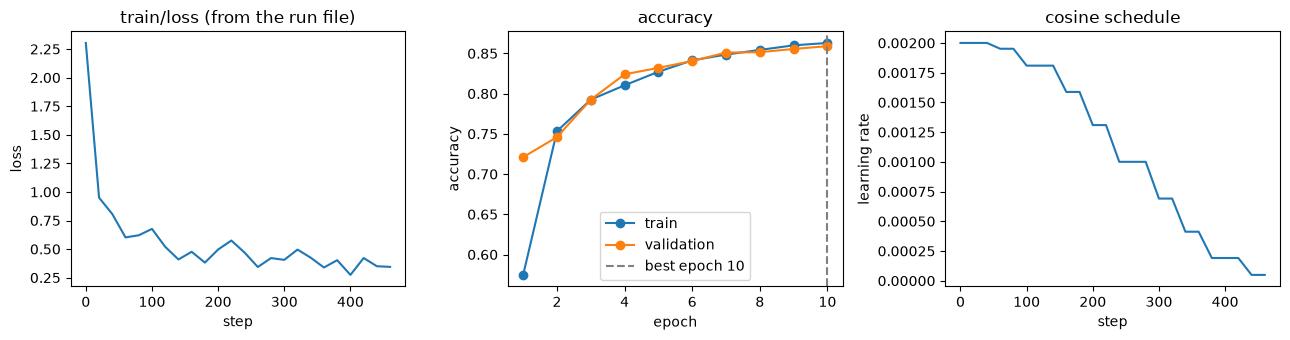

final train–val accuracy gap: +0.0040 → no strong overfitting yet


In [38]:
cnn_logged = read_offline_run(cnn_run_dir)
val_history = pd.DataFrame([row for row in cnn_logged["history"] if "val/acc" in row])[["epoch", "train/acc", "val/loss", "val/acc"]]
train_history = pd.DataFrame([row for row in cnn_logged["history"] if "train/loss" in row])[["_step", "train/loss", "train/lr"]]
print("config from file matches:", cnn_logged["config"] == project_config)
print("summary from file:", {k: cnn_logged["summary"][k] for k in ("val/acc", "val/loss", "best_epoch", "stopped_epoch")})
artifact_record = cnn_logged["artifacts"][0]
print(f"model artifact {artifact_record['name']} aliases {artifact_record['aliases']} | "
      f"checkpoint digest matches file: {artifact_record['files'][checkpoint_file.name]['digest'] == md5_base64(checkpoint_file)}")
assert np.allclose(val_history["val/acc"], [e["val_acc"] for e in epoch_log])
assert cnn_logged["summary"]["val/acc"]["max"] == best_acc

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
axes[0].plot(train_history["_step"], train_history["train/loss"])
axes[0].set(xlabel="step", ylabel="loss", title="train/loss (from the run file)")
axes[1].plot(val_history["epoch"], val_history["train/acc"], marker="o", label="train")
axes[1].plot(val_history["epoch"], val_history["val/acc"], marker="o", label="validation")
axes[1].axvline(best_epoch, color="gray", linestyle="--", label=f"best epoch {best_epoch}")
axes[1].set(xlabel="epoch", ylabel="accuracy", title="accuracy")
axes[1].legend()
axes[2].plot(train_history["_step"], train_history["train/lr"])
axes[2].set(xlabel="step", ylabel="learning rate", title="cosine schedule")
plt.tight_layout()
plt.show()

gap = val_history["train/acc"].iloc[-1] - val_history["val/acc"].iloc[-1]
print(f"final train–val accuracy gap: {gap:+.4f} → {'overfitting is starting' if gap > 0.03 else 'no strong overfitting yet'}")

### Step 6 — Final test evaluation (once) and conclusions

In [39]:
def test_accuracy(model):
    model.eval()
    with torch.no_grad():
        return (model(X_te).argmax(1) == y_te).float().mean().item()


with torch.no_grad():
    test_pred = best_cnn(X_te).argmax(1)
per_class_test = pd.Series({CLASSES[c]: float((test_pred[y_te == c] == c).float().mean()) for c in range(len(CLASSES))})
results = {"small CNN (best checkpoint)": test_accuracy(best_cnn), "MLP (section 4)": test_accuracy(mlp),
           "softmax regression (section 2)": test_accuracy(softmax_model)}

with wandb.init(project=PROJECT, name="final-test", job_type="test", config={"checkpoint_digest": md5_base64(checkpoint_file)}) as run:
    run.summary.update({"test/acc_cnn": results["small CNN (best checkpoint)"], "test/acc_mlp": results["MLP (section 4)"],
                        "test/acc_softmax": results["softmax regression (section 2)"]})
    run.log({"test/per_class_accuracy": wandb.Table(dataframe=per_class_test.rename("accuracy").rename_axis("class").reset_index())})

for name, acc in results.items():
    print(f"{name:32s} test accuracy {acc:.4f}")
cnn_gain = results["small CNN (best checkpoint)"] - results["MLP (section 4)"]
print(f"\nCNN vs MLP: {cnn_gain:+.4f} ({'the convolutional features help' if cnn_gain > 0 else 'no gain from convolutions at this size'})")
print(f"validation {best_acc:.4f} vs test {results['small CNN (best checkpoint)']:.4f} (gap {best_acc - results['small CNN (best checkpoint)']:+.4f})")
print(f"hardest class on test: {per_class_test.idxmin()} ({per_class_test.min():.3f}); easiest: {per_class_test.idxmax()} ({per_class_test.max():.3f})")

small CNN (best checkpoint)      test accuracy 0.8500
MLP (section 4)                  test accuracy 0.8055
softmax regression (section 2)   test accuracy 0.7550

CNN vs MLP: +0.0445 (the convolutional features help)
validation 0.8590 vs test 0.8500 (gap +0.0090)
hardest class on test: Shirt (0.490); easiest: Bag (0.975)


**Stretch goals**
1. Create a W&B account, set `WANDB_MODE=online`, `wandb sync` the `_outputs/wandb_home/wandb/offline-run-*` folders, and explore the lineage graph for `small-cnn-fashion`.
2. Run the sweep from section 9 (online) over `channels`, `dropout`, and `lr` with Hyperband, and compare the winner's test accuracy with this run.
3. Add data augmentation (random crops / flips are wrong for some classes — think about which) and check whether the Shirt/T-shirt confusion shrinks.
4. Log the model to MLflow as well (`mlflow.pytorch.log_model`) and register it with a `champion` alias.

### 🗣️ How to talk about this in an interview
- "I tracked a CNN on FashionMNIST with W&B: all hyperparameters and the dataset digest in `config`, per-step loss and learning rate, per-epoch validation metrics, and gradient histograms via `watch`."
- "Early stopping monitored validation accuracy with patience 2; I set `define_metric(summary='max')` so the run's summary reflects the best epoch, and saved exactly that checkpoint as a versioned model artifact with `best` and `epoch-N` aliases."
- "Error analysis used a W&B table of the most confident mistakes plus a confusion matrix — the dominant errors were between visually similar upper-body garments."
- "Because the cluster was offline, I read the run's transaction log back and asserted the logged curves, summary, and checkpoint hash matched the training loop — then `wandb sync` uploads the same data."
- "The test set was used once at the end to compare the CNN against the MLP and softmax baselines."

## 🎤 Interview Q&A

Try answering **out loud** before opening each answer.

### 🧠 Concepts

**Q1. Explain W&B's core objects: project, run, config, history, and summary.**

<details><summary>Show answer</summary>

- **30-second answer:** A project groups runs. A run is one execution started by `wandb.init`. `config` holds the run's inputs (hyperparameters, data version). Each `run.log` call adds values to the run's **history** at a step. The **summary** holds one value per key that represents the run in tables — by default the last logged value.
- **Go deeper:** `define_metric(name, summary="max"/"min"/"mean")` changes the summary to an aggregate, `run.summary[key] = v` overrides it, and `define_metric("val/*", step_metric="epoch")` changes the x-axis. `group` and `job_type` organise related runs (CV folds, data-prep vs train).
- **❌ Common wrong answer:** "The summary is the best value of each metric."

</details>

**Q2. What happens if you log with a step smaller than the current one?**

<details><summary>Show answer</summary>

- **30-second answer:** The data is dropped — steps must increase monotonically. Logs with the same step are merged into one row.
- **Go deeper:** The usual cause is mixing a global batch step for training with an epoch number for validation. Keep one increasing global step and log `epoch` as a value with `define_metric(..., step_metric="epoch")`.
- **❌ Common wrong answer:** "W&B re-sorts rows by step, so order doesn't matter."

</details>

**Q3. What are W&B artifacts and how do they give you lineage?**

<details><summary>Show answer</summary>

- **30-second answer:** Artifacts are named, typed, versioned bundles of files (`dataset:v3`, `model:v7`) with per-file MD5 digests. A run that logs an artifact is its producer; a run that calls `use_artifact` is a consumer, so W&B can draw the graph dataset → training run → model → evaluation run.
- **Go deeper:** Identical content doesn't create a new version (content-addressed); aliases like `latest`, `best`, `production` point at versions; reference artifacts can track files in S3/GCS without copying them. `use_artifact`/`download` need the server.
- **❌ Common wrong answer:** "Artifacts are just file uploads with no versioning."

</details>

**Q4. How do W&B sweeps work, and how do grid, random, and Bayesian search differ?**

<details><summary>Show answer</summary>

- **30-second answer:** You define a search space and target metric; `wandb.sweep` creates a controller on the server; any number of `wandb agent` processes ask it for a configuration, run the training function (which reads `wandb.config`), and report the metric. Grid tries every combination, random samples independently, and Bayesian search fits a surrogate model to choose promising points.
- **Go deeper:** Random is embarrassingly parallel and strong when few hyperparameters matter; Bayes needs fewer trials for expensive runs but is sequential. Use `log_uniform_values` for learning rates. Early termination (Hyperband) stops weak runs at brackets.
- **❌ Common wrong answer:** "Bayesian search is always better, so never use random search."

</details>

**Q5. What does Hyperband do, and what's its risk?**

<details><summary>Show answer</summary>

- **30-second answer:** It runs many configurations on a small budget and, at checkpoints (brackets), keeps only the best fraction (`1/eta`), giving survivors more budget — successive halving, repeated with several starting budgets.
- **Go deeper:** In W&B, brackets come from `min_iter` and `eta` (e.g. 3, 9, 27, 81) or from `max_iter`, `eta`, `s`; an iteration is one logged value of the target metric. Risk: slow starters (warm-up schedules, large models) get killed early — raise `min_iter`.
- **❌ Common wrong answer:** "Hyperband is a Bayesian optimizer."

</details>

### 💻 Coding

**Q6. Instrument a PyTorch training loop with W&B.**

<details><summary>Show answer</summary>

- **30-second answer:**
  ```python
  with wandb.init(project="p", config=cfg) as run:
      model = Net(run.config.hidden); run.watch(model, log="gradients", log_freq=100)
      run.define_metric("val/acc", summary="max")
      for epoch in range(run.config.epochs):
          for x, y in loader:
              loss = step(x, y); run.log({"train/loss": loss.item()}, step=global_step); global_step += 1
          run.log({"val/acc": evaluate(model), "epoch": epoch}, step=global_step)
  ```
- **Go deeper:** Read hyperparameters from `run.config` so sweeps can override them; log `.item()` numbers; save the best checkpoint and log it as an artifact with aliases.
- **❌ Common wrong answer:** Calling `wandb.init` inside the epoch loop, or logging tensors that keep the graph alive.

</details>

**Q7. Log a trained model as an artifact correctly.**

<details><summary>Show answer</summary>

- **30-second answer:** `torch.save(model.state_dict(), path)` (or `with open(...)` for pickle) so the file is closed; then `art = wandb.Artifact("my-model", type="model", metadata={...}); art.add_file(path); run.log_artifact(art, aliases=["best"])`.
- **Go deeper:** Put the metric and dataset version in metadata; use `add_dir` for multi-file models; link to the registry for production.
- **❌ Common wrong answer:** `add_file` inside a still-open `open()` block — the artifact captures a truncated or empty file.

</details>

### 🐛 Debugging Scenarios

**Q8. Validation metrics are missing from your charts although the code calls `run.log`. What's wrong?**

<details><summary>Show answer</summary>

- **30-second answer:** Almost certainly the step went backwards (e.g. `step=epoch` after logging training at `step=global_step`), so W&B dropped those rows.
- **Go deeper:** Use one increasing step and `define_metric("val/*", step_metric="epoch")`; or omit `step` and let W&B count.
- **❌ Common wrong answer:** "W&B is rate-limiting me."

</details>

**Q9. In a notebook, your first run suddenly shows as finished and logging to it raises "Run is finished". Why?**

<details><summary>Show answer</summary>

- **30-second answer:** A second `wandb.init()` was called while the first run was active; in notebooks the default is to finish the previous run and start a new one (in scripts it returns the existing run).
- **Go deeper:** Use `with wandb.init(...) as run:` per run; control the behaviour explicitly with the `reinit` setting when you really need several runs in one process.
- **❌ Common wrong answer:** "W&B crashed; restart the kernel."

</details>

**Q10. Your company self-hosts W&B. Which environment variable points the client at it — `MLFLOW_TRACKING_URI`?**

<details><summary>Show answer</summary>

- **30-second answer:** No — `WANDB_BASE_URL` (plus `WANDB_API_KEY` from that server, or `wandb login --host <url>`). `MLFLOW_TRACKING_URI` is MLflow's variable.
- **Go deeper:** Offline clusters can write with `WANDB_MODE=offline` and `wandb sync` from a machine that can reach the server.
- **❌ Common wrong answer:** Setting `MLFLOW_TRACKING_URI`, or hard-coding the API key in the notebook.

</details>

### 🏗️ Design

**Q11. Design experiment tracking for a 20-person research team training large models on a shared GPU cluster without internet.**

<details><summary>Show answer</summary>

- **30-second answer:** Either a self-managed W&B server inside the network (clients set `WANDB_BASE_URL`) or offline mode with a sync job on a gateway node. Conventions: project per research area, mandatory config keys (git commit, dataset artifact version), `group` for multi-node/multi-seed runs, log scalars every N steps and checkpoints as artifacts only at best/final.
- **Go deeper:** Sweeps with agents pinned one per GPU; Hyperband to save compute; reports for weekly reviews; retention policies for large artifacts; hand the chosen checkpoint to the production registry (W&B Registry or MLflow).
- **❌ Common wrong answer:** "Everyone logs to their personal account and shares screenshots."

</details>

**Q12. When would you choose W&B over MLflow, and when would you use both?**

<details><summary>Show answer</summary>

- **30-second answer:** W&B for research-heavy deep-learning teams that want live dashboards, media and tables, built-in sweeps, and collaboration, and are fine with SaaS or licensing a server. MLflow when you need fully open-source self-hosting, data residency, model packaging, registry aliases, and serving. Both: W&B during research, MLflow or a cloud registry for the production lifecycle.
- **Go deeper:** The concepts map one-to-one (config↔params, log↔log_metric with step, summary↔latest metric, artifacts↔artifacts/logged models), so migrating tracking code is mechanical; the organizational choice is about hosting, cost, and existing platforms (Databricks → MLflow).
- **❌ Common wrong answer:** "They do completely different things."

</details>

## 🧪 Quick Quiz

Predict the answer, then reveal.

**1.** A run logs `loss` = 0.9, 0.5, 0.7 with no `define_metric`. What is `run.summary["loss"]`?
<details><summary>Answer</summary>

`0.7` — the default summary is the last logged value.
</details>

**2.** After `run.define_metric("acc", summary="max")`, the run logs `acc` = 0.5, 0.9, 0.7. What does the summary hold for `acc`?
<details><summary>Answer</summary>

`{"max": 0.9}` — a dict with the requested aggregate (not a plain number).
</details>

**3.** `run.log({"x": 1}, step=5)` then `run.log({"x": 2}, step=3)` then `run.log({"x": 3}, step=6)`. Which steps appear in the history?
<details><summary>Answer</summary>

Steps **5 and 6**. The step-3 row goes backwards and is dropped without an exception.
</details>

**4.** With `WANDB_MODE=offline` and no API key, you call `wandb.sweep(config, project="p")`. What happens?
<details><summary>Answer</summary>

It raises `UsageError: No API key configured` — the sweep controller lives on the W&B server.
</details>

**5.** In a Jupyter notebook, `run1 = wandb.init()` then `run2 = wandb.init()` without finishing `run1`. Is `run2 is run1`, and can you still log to `run1`?
<details><summary>Answer</summary>

No and no: in notebooks the second call finishes `run1` and returns a new run, so `run1.log(...)` raises `UsageError` (run is finished). In a plain Python script the default instead returns the same active run.
</details>

## 📚 Resources

### 📖 Official Docs
- [Experiments overview](https://docs.wandb.ai/models/track/) — `wandb.init`, config, logging, summaries
- [Customize log axes](https://docs.wandb.ai/models/track/log/customize-logging-axes/) — steps, `define_metric`, and custom x-axes
- [Artifacts overview](https://docs.wandb.ai/models/artifacts/) — versioning, aliases, and lineage
- [Sweeps overview](https://docs.wandb.ai/models/sweeps/) — controller, agents, and search methods
- [Environment variables](https://docs.wandb.ai/models/track/environment-variables/) — `WANDB_MODE`, `WANDB_BASE_URL`, `WANDB_DIR`, and friends

### 🎥 Videos
- [Weights & Biases — Track Your PyTorch Machine Learning Experiments with Weights & Biases](https://www.youtube.com/watch?v=KESSYZExK44) (1 min) — the official one-minute tour of `init`, `log`, and `watch` in a PyTorch loop
- [Weights & Biases — Using W&B beyond experiment tracking](https://www.youtube.com/watch?v=_2DNYGv3jiM) (4 min) — official walkthrough of sweeps and interactive tables
- [The Full Stack — Experiment Management (6) - Infrastructure and Tooling - Full Stack Deep Learning](https://www.youtube.com/watch?v=N83eejieeRg) (3 min) — why experiment management matters and how trackers compare

### 📄 Papers
- [Li et al. (2018) — Hyperband: A Novel Bandit-Based Approach to Hyperparameter Optimization](https://arxiv.org/abs/1603.06560) — the early-termination algorithm behind sweeps
- [Bergstra & Bengio (2012) — Random Search for Hyper-Parameter Optimization](https://www.jmlr.org/papers/v13/bergstra12a.html) — why random search beats grid search
- [Snoek, Larochelle & Adams (2012) — Practical Bayesian Optimization of Machine Learning Algorithms](https://arxiv.org/abs/1206.2944) — the Bayesian search idea

### 📘 Books & Courses
- [Lab 4: Experiment Management](https://fullstackdeeplearning.com/course/2022/lab-4-experiment-management/) — Full Stack Deep Learning 2022, a full W&B workflow for a real model
- [MLOps Zoomcamp (free course)](https://github.com/DataTalksClub/mlops-zoomcamp) — DataTalks.Club, experiment tracking through deployment and monitoring

### 🏋️ Practice
- [wandb/examples](https://github.com/wandb/examples) — runnable examples for PyTorch, Keras, Hugging Face, sweeps, and artifacts

## 📝 Summary Cheat Sheet

| Concept | What it does | Key API |
|---|---|---|
| Run | one tracked execution | `with wandb.init(project=, name=, config=, job_type=) as run:` |
| Modes | where data goes | `WANDB_MODE=online / offline / disabled`, `wandb sync <folder>` |
| Config | run inputs | `run.config.update({...})`, `run.config.lr` |
| Log | history rows at steps | `run.log({"train/loss": v}, step=global_step)` — steps never go backwards |
| Summary | one value per key | last value by default; `run.define_metric("val/acc", summary="max")`; `run.summary["best"] = v` |
| Custom x-axis | plot vs epoch | `run.define_metric("val/*", step_metric="epoch")` |
| Gradients | histograms | `run.watch(model, log="all", log_freq=50)` |
| Media & tables | error analysis | `wandb.Image`, `wandb.Histogram`, `wandb.Table(columns=/dataframe=)`, `wandb.plot.confusion_matrix` |
| Artifacts | versioned files + lineage | write & close → `wandb.Artifact(name, type)`, `add_file`, `run.log_artifact(art, aliases=[...])`, `run.use_artifact` (online) |
| Sweeps | hyperparameter search | config with `method`, `metric`, `parameters`, `early_terminate: hyperband` → `wandb.sweep` + `wandb.agent` (server) |
| Self-hosted | point at your server | `WANDB_BASE_URL`, `wandb login --host` |

## ➡️ What's Next

**[03 · DVC](03_DVC.ipynb)** — trackers record *what happened* in each run; DVC versions the **data and pipeline steps** themselves in Git, so anyone can reproduce the exact dataset and model with `dvc repro`.